# Section 5.2: Test 1 - Ontological Innovation in Sensory Modalities

This notebook analyzes AI-generated proposals for ninth sensory modalities and determines whether they represent genuine ontological innovation or recombination of existing eight modalities.

In [32]:
import json, warnings
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from scipy.spatial import ConvexHull, Delaunay
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Project-wide style
plt.style.use("setups/plotstyles.mplstyle")

Path("results/test1").mkdir(parents=True, exist_ok=True)
path_test1_results = "results/test1_cleaned.csv"
path_test1_ai_proposals = "results/test1_ontological_innovation/ai_proposals.json"
path_modality_descriptions = "data/modality_descriptions.json"

In [34]:
# Shared visualization palettes / colour constants.
import importlib
import setups.viz_styles as _viz_styles

importlib.reload(_viz_styles)

from setups.viz_styles import (
    WHITE_SKY_CMAP,
    SKY_WHITE_GRAY_CMAP,
    BLUE_GRAY_RAMP,
    THRESHOLD_COLOR,
    MODEL_VISIBLE_COLORS,
)

from setups.thresholds import (
    T1_NOVELTY_FRONTIER_SIM_THRESHOLD as NOVELTY_FRONTIER_SIM_THRESHOLD,
    EMBED_MODEL_NAME,
)

## 1. Load AI-Generated Modality Proposals

### Modality Config Contract

This notebook expects `data/modality_descriptions.json` to use the shared schema:

- `modalities_order`: ordered list of modality ids.
- `modality_descriptions`: mapping `{modality -> description text}`.
- `extension_keywords`: mapping `{modality -> [keywords...]}`.

All modality-dependent analysis should read from these loaded structures instead of hardcoded modality lists or keyword maps.

In [35]:
# Load modality descriptions and keywords from shared JSON
modality_descriptions_file = Path(path_modality_descriptions)
if not modality_descriptions_file.exists():
    raise FileNotFoundError(f"Missing file: {modality_descriptions_file}")

with open(modality_descriptions_file, "r", encoding="utf-8") as f:
    modality_config = json.load(f)

required_config_keys = ["modalities_order", "modality_descriptions", "extension_keywords"]
missing_config_keys = [k for k in required_config_keys if k not in modality_config]
if missing_config_keys:
    raise KeyError(
        f"Missing required keys in {modality_descriptions_file}: {missing_config_keys}"
    )

modalities = [str(m).strip().lower() for m in modality_config["modalities_order"]]
modality_descriptions = modality_config["modality_descriptions"]
extension_keywords = modality_config["extension_keywords"]

missing_modalities = [m for m in modalities if not str(modality_descriptions.get(m, "")).strip()]
if missing_modalities:
    raise KeyError(
        f"Missing modality descriptions in {modality_descriptions_file}: {missing_modalities}"
    )

missing_extension_keywords = [m for m in modalities if m not in extension_keywords]
if missing_extension_keywords:
    raise KeyError(
        f"Missing extension keywords in {modality_descriptions_file}: {missing_extension_keywords}"
    )

modalities_df = pd.DataFrame(
    {
        "modality": modalities,
        "description": [modality_descriptions[m] for m in modalities],
        "extension_keywords": [", ".join(extension_keywords[m]) for m in modalities],
    }
)

print(f"Loaded modality configuration for {len(modalities)} modalities.")
display(modalities_df)

Loaded modality configuration for 8 modalities.


,modality,description,extension_keywords
0,visual,Visual sensation detects electromagnetic radia...,"electromagnetic, radiation, spectrum, waveleng..."
1,auditory,Auditory sensation detects mechanical sound wa...,"sound, acoustic, frequency, infrasound, ultras..."
2,tactile,Tactile sensation detects mechanical vibration...,"pressure, mechanical, touch, vibration, surface"
3,olfactory,Olfactory sensation detects airborne chemical ...,"chemical, molecule, scent, smell, airborne"
4,gustatory,Gustatory sensation detects dissolved chemical...,"taste, chemical, molecule, dissolved"
5,proprioceptive,Proprioceptive sensation detects body position...,"joint, muscle, tendon, body position, kinesthetic"
6,vestibular,"Vestibular sensation detects head position, li...","vestibular, equilibrium, balance, acceleration..."
7,interoceptive,Interoceptive sensation detects internal physi...,"heartbeat, respiration, hunger, thirst, fatigu..."


In [36]:
# Load processed Test 1 results exported by 2-test1-ontological-innovation.ipynb
test1_results = pd.read_csv(path_test1_results)

print(test1_results.columns.tolist())

# Support both legacy and current schemas
preview_candidates = [
    "model",
    "proposal_id",
    "proposal_name",      # current
    "modality_name",      # legacy
    "is_novel",           # current novelty label
    "ontologically_novel",# legacy novelty label
    "novelty_score",      # legacy novelty score
    "max_similarity",
]
preview_cols = [c for c in preview_candidates if c in test1_results.columns]

print(f"Preview columns used: {preview_cols}")
test1_results[preview_cols].head()

['proposal_id', 'proposal_name', 'model', 'is_extension', 'is_hybrid', 'is_functional_recomb', 'is_traceable', 'related_modalities', 'inside_convex_hull', 'closest_modality', 'max_similarity', 'avg_similarity', 'lit_matches', 'lit_best_score', 'lit_best_text', 'lit_best_title', 'lit_best_source_type', 'lit_best_evidence_tier', 'novelty_semantic_proxy', 'novelty_frontier_distance_proxy', 'continuous_novelty_score', 'is_novel']
Preview columns used: ['model', 'proposal_id', 'proposal_name', 'is_novel', 'max_similarity']


,model,proposal_id,proposal_name,is_novel,max_similarity
0,deepseek-v3.2,sample_000,Chronesthesia,NO,0.448774
1,mistral-large,sample_001,Temporal Resonance Perception (TRP),NO,0.297537
2,deepseek-v3.2,sample_002,Chronoperception,NO,0.348915
3,llama-3.3-70b-instruct,sample_003,Chronoceptive Modality,NO,0.395404
4,deepseek-v3.2,sample_004,Temporoceptive,NO,0.306830


In [37]:
test1_results.loc[:, ['is_extension', 'is_hybrid', 'is_functional_recomb', 'is_traceable','inside_convex_hull']]

,is_extension,is_hybrid,is_functional_recomb,is_traceable,inside_convex_hull
0,False,False,False,True,True
1,True,False,False,True,True
2,False,False,False,True,True
3,False,False,False,True,True
4,False,False,True,True,True
...,...,...,...,...,...
163,False,False,False,True,True
164,True,True,False,True,True
165,False,False,False,True,True
166,False,False,False,True,True


## 2. Structural Analysis: Decomposition into Existing Modalities

In [38]:
# Harmonize schema for downstream cells while using results/test1_cleaned.csv as source of truth.
test1_results = pd.read_csv(path_test1_results)

In [39]:
def _is_blank(series: pd.Series) -> pd.Series:
    return series.isna() | series.astype(str).str.strip().eq("")

# Harmonize to analysis schema based on results/test1_cleaned.csv columns.
# proposal_name = AI-generated theory label
test1_results["proposal_name"] = test1_results["proposal_name"].astype(str).str.strip()

name_blank = _is_blank(test1_results["closest_modality"])
test1_results.loc[name_blank, "closest_modality"] = test1_results.loc[name_blank, "proposal_name"]

# Use canonical proposal descriptions exported by 2-test1-ontological-innovation.ipynb.
proposals_json_file = Path(path_test1_ai_proposals)
if not proposals_json_file.exists():
    raise FileNotFoundError(
        f"Missing canonical proposals file: {proposals_json_file}. "
        "Run 2-test1-ontological-innovation.ipynb through proposal construction first."
    )

with proposals_json_file.open("r", encoding="utf-8") as f:
    proposals_records = json.load(f)

proposals_df = pd.DataFrame(proposals_records)
required_proposal_cols = ["proposal_id", "description"]
missing_proposal_cols = [c for c in required_proposal_cols if c not in proposals_df.columns]
if missing_proposal_cols:
    raise KeyError(
        f"Missing required columns in {proposals_json_file}: {missing_proposal_cols}"
    )

# Merge canonical descriptions by proposal_id; this ensures both notebooks embed the same text.
proposal_desc_map = proposals_df.set_index("proposal_id")["description"].astype(str)
test1_results["description"] = test1_results["proposal_id"].map(proposal_desc_map)

desc_blank = _is_blank(test1_results["description"])
test1_results.loc[desc_blank, "description"] = test1_results.loc[desc_blank, "proposal_name"]

# Derive novelty score from similarity because cleaned CSV has no explicit novelty_score.
sim = pd.to_numeric(test1_results["max_similarity"], errors="coerce")
test1_results["novelty_score"] = (1.0 - sim).clip(lower=0.0, upper=1.0)

test1_results["is_range_extension"] = test1_results["is_extension"].fillna(False).astype(bool)
test1_results["is_hybrid"] = test1_results["is_hybrid"].fillna(False).astype(bool)

# Prefer source `is_traceable`; derive it from lit_matches for legacy exports.
if "is_traceable" in test1_results.columns:
    test1_results["is_traceable"] = test1_results["is_traceable"].fillna(False).astype(bool)
else:
    test1_results["is_traceable"] = pd.to_numeric(
        test1_results.get("lit_matches", 0), errors="coerce"
    ).fillna(0).gt(0)

print(f"Loaded {len(test1_results)} proposals from {path_test1_results}")
print(f"Merged canonical descriptions from: {proposals_json_file}")
preview_cols = [
    "model", "proposal_id", "proposal_name",
    "description", "novelty_score", "max_similarity", "is_traceable",
    "closest_modality",
 ]
display(test1_results[preview_cols].head())

Loaded 168 proposals from results/test1_cleaned.csv
Merged canonical descriptions from: results/test1_ontological_innovation/ai_proposals.json


,model,proposal_id,proposal_name,description,novelty_score,max_similarity,is_traceable,closest_modality
0,deepseek-v3.2,sample_000,Chronesthesia,"Detection of fundamental, quantum-level fluctu...",0.551226,0.448774,True,PROPRIOCEPTIVE
1,mistral-large,sample_001,Temporal Resonance Perception (TRP),"Detection of minute, localized distortions in ...",0.702463,0.297537,True,VISUAL
2,deepseek-v3.2,sample_002,Chronoperception,Direct detection of temporal gradients and pha...,0.651085,0.348915,True,PROPRIOCEPTIVE
3,llama-3.3-70b-instruct,sample_003,Chronoceptive Modality,The chronoceptive modality detects the tempora...,0.604596,0.395404,True,INTEROCEPTIVE
4,deepseek-v3.2,sample_004,Temporoceptive,Direct detection of the local rate of time flo...,0.693170,0.306830,True,VESTIBULAR


## 3. Literature Traceability Analysis

In [40]:
if "is_traceable" in test1_results.columns:
    traceable = test1_results["is_traceable"].fillna(False).astype(bool)
else:
    traceable = pd.to_numeric(test1_results.get("lit_matches", 0), errors="coerce").fillna(0).gt(0)
mean_sim = pd.to_numeric(test1_results["max_similarity"], errors="coerce").mean()

print("\nLiterature Traceability (from cleaned data):")
print(f"Traceable to literature: {int(traceable.sum())} ({traceable.mean():.1%})")
print(f"Mean similarity to known concepts: {mean_sim:.3f}")


Literature Traceability (from cleaned data):
Traceable to literature: 165 (98.2%)
Mean similarity to known concepts: 0.305


## 4. Embedding Space Analysis

In [41]:
def select_embedding_texts(df: pd.DataFrame) -> tuple[list[str], str]:
    """Pick the best available text field with non-empty and diverse content."""
    candidates = ["description", "proposal_name", "closest_modality", "lit_best_text"]
    best_col = None
    best_score = -1.0
    best_series = None

    for col in candidates:
        if col not in df.columns:
            continue
        s = df[col].fillna("").astype(str).str.strip()
        nonempty = s[s != ""]
        if nonempty.empty:
            continue
        coverage = len(nonempty) / len(df) if len(df) else 0.0
        diversity = nonempty.nunique() / len(nonempty)
        score = 0.7 * coverage + 0.3 * diversity
        if score > best_score:
            best_score = score
            best_col = col
            best_series = s

    if best_series is None:
        return ([""] * len(df), "<empty>")

    # Fill remaining blanks with fallback name fields to avoid empty embeddings.
    fallback_cols = [c for c in ["proposal_name", "closest_modality", "lit_best_text"] if c in df.columns and c != best_col]
    out = best_series.copy()
    for c in fallback_cols:
        fb = df[c].fillna("").astype(str).str.strip()
        out = out.where(out != "", fb)

    return (out.fillna("").astype(str).tolist(), best_col)

proposal_texts, selected_text_col = select_embedding_texts(test1_results)

missing_modalities = [m for m in modalities if m not in modality_descriptions]
if missing_modalities:
    raise KeyError(
        f"Missing modality descriptions in {modality_descriptions_file}: {missing_modalities}"
    )

existing_descriptions = [modality_descriptions[m] for m in modalities]

n_dims = 384
existing_embeddings = np.random.randn(len(existing_descriptions), n_dims)

# One embedding per proposal (placeholder around mean of existing)
proposal_embeddings = (
    existing_embeddings.mean(axis=0)
    + np.random.randn(len(test1_results), n_dims) * 0.3
)

def test_convex_hull_membership(existing_points: np.ndarray,
                                new_points: np.ndarray):
    """Test if new points lie within convex hull of existing points."""
    pca = PCA(n_components=2)
    existing_2d = pca.fit_transform(existing_points)
    new_2d = pca.transform(new_points)

    hull = ConvexHull(existing_2d)
    delaunay = Delaunay(existing_2d)
    inside = delaunay.find_simplex(new_2d) >= 0
    return inside, existing_2d, new_2d, hull

inside_hull, existing_2d, new_2d, hull = test_convex_hull_membership(
    existing_embeddings, proposal_embeddings
)

# Attach to the cleaned proposals DataFrame
test1_results["inside_convex_hull"] = inside_hull

print("\nEmbedding Space Analysis:")
print(f"Text source used for embeddings: {selected_text_col}")
print(
    f"Proposals inside training convex hull: {inside_hull.sum()} "
    f"({inside_hull.mean():.1%})"
)
print(
    f"Proposals outside convex hull: {(~inside_hull).sum()} "
    f"({(~inside_hull).mean():.1%})"
)


Embedding Space Analysis:
Text source used for embeddings: description
Proposals inside training convex hull: 168 (100.0%)
Proposals outside convex hull: 0 (0.0%)


In [42]:
# 2) Prepare texts from shared modality config loaded at notebook start
missing_modalities = [m for m in modalities if m not in modality_descriptions]
if missing_modalities:
    raise KeyError(
        f"Missing modality descriptions in {modality_descriptions_file}: {missing_modalities}"
    )

training_descriptions = [modality_descriptions[m] for m in modalities]

# Canonical source alignment: use proposal descriptions merged from ai_proposals.json.
if "description" in test1_results.columns:
    desc_series = test1_results["description"].fillna("").astype(str).str.strip()
    if (desc_series != "").all():
        proposal_texts = desc_series.tolist()
        selected_text_col = "description"
    else:
        # Fallback only for missing description rows.
        fallback_col = "proposal_name" if "proposal_name" in test1_results.columns else "lit_best_text"
        fallback_series = test1_results.get(fallback_col, pd.Series([""] * len(test1_results))).fillna("").astype(str).str.strip()
        proposal_texts = desc_series.where(desc_series != "", fallback_series).tolist()
        selected_text_col = f"description (+ {fallback_col} fallback)"
else:
    fallback_col = "proposal_name" if "proposal_name" in test1_results.columns else "lit_best_text"
    proposal_texts = test1_results.get(fallback_col, pd.Series([""] * len(test1_results))).fillna("").astype(str).tolist()
    selected_text_col = fallback_col

# 3) Embed with the same model
embedder = SentenceTransformer(EMBED_MODEL_NAME)
training_embeddings = embedder.encode(training_descriptions)
proposal_embeddings = embedder.encode(proposal_texts)

# 4) PCA + convex hull (aligned with 2-test1-ontological-innovation.ipynb)
target_dim = min(3, training_embeddings.shape[0] - 1)
pca = PCA(n_components=target_dim)
training_emb_reduced = pca.fit_transform(training_embeddings)
proposal_emb_reduced = pca.transform(proposal_embeddings)

training_hull = ConvexHull(training_emb_reduced)

def point_in_convex_hull_3d(point_reduced, hull, tol=1e-4):
    A = hull.equations[:, :-1]
    b = hull.equations[:, -1]
    vals = A @ point_reduced + b
    # Numerical guard: near-zero positive residuals are boundary points, not true outside points.
    return bool(np.all(vals <= tol)), float(np.maximum(vals, 0.0).max())

inside_hull_3d = []
outside_violation = []
for i in range(len(test1_results)):
    inside, violation = point_in_convex_hull_3d(proposal_emb_reduced[i], training_hull)
    inside_hull_3d.append(inside)
    outside_violation.append(violation)

inside_hull_3d = np.array(inside_hull_3d)
outside_violation = np.array(outside_violation)

# 5) 2D projection for plotting + optional 2D diagnostic membership
training_2d = training_emb_reduced[:, :2]
proposal_2d = proposal_emb_reduced[:, :2]
inside_hull_2d = Delaunay(training_2d).find_simplex(proposal_2d) >= 0

# Canonical result must match the main test1 notebook: hull status from 3D PCA space.
inside_hull = inside_hull_3d
test1_results["inside_convex_hull"] = inside_hull_3d
test1_results["inside_convex_hull_2d_plot"] = inside_hull_2d

print(f"Embedding text source: {selected_text_col}")
print(f"Inside hull (3D PCA canonical): {inside_hull_3d.sum()} / {len(inside_hull_3d)}")
print(f"Outside hull (3D PCA canonical): {(~inside_hull_3d).sum()} / {len(inside_hull_3d)}")
print(f"Inside hull (2D projected diagnostic): {inside_hull_2d.sum()} / {len(inside_hull_2d)}")
print(f"3D vs 2D mismatch count: {(inside_hull_3d != inside_hull_2d).sum()}")
print(f"Max 3D hull violation (diagnostics): {outside_violation.max():.2e}")

Embedding text source: description
Inside hull (3D PCA canonical): 168 / 168
Outside hull (3D PCA canonical): 0 / 168
Inside hull (2D projected diagnostic): 168 / 168
3D vs 2D mismatch count: 0
Max 3D hull violation (diagnostics): 0.00e+00


## 5. Visualization: Embedding Space with Convex Hull

In [43]:
def _modality_label(text: str) -> str:
    return str(text).replace("_", " ").strip().capitalize()


def plot_embedding_space(
    training_emb_reduced: np.ndarray,
    proposal_emb_reduced: np.ndarray,
    modalities: list[str],
    inside_hull: np.ndarray,
    save_path: str,
    membership_label: str = "3D PCA",
    annotate_proposals: bool = False,
) -> None:
    """2D PCA projection: training modalities and proposal points."""
    training_2d = training_emb_reduced[:, :2]
    proposal_2d = proposal_emb_reduced[:, :2]

    fig, ax = plt.subplots(figsize=(7, 5))
    train_scatter = ax.scatter(
        training_2d[:, 0],
        training_2d[:, 1],
        s=60,
        c=BLUE_GRAY_RAMP[2],
        marker="o",
        alpha=0.75,
        edgecolors="black",
        label="Training modalities",
    )

    # Shared label placement rule for all modalities.
    for index, modality in enumerate(modalities):
        label = _modality_label(modality)
        ax.annotate(
            label,
            (training_2d[index, 0], training_2d[index, 1]),
            fontsize=8,
            xytext=(8, 0),
            textcoords="offset points",          
            ha="left",
            va="center",
            clip_on=False,
        )

    if len(training_2d) >= 3:
        for simplex in ConvexHull(training_2d).simplices:
            ax.plot(
                training_2d[simplex, 0], 
                training_2d[simplex, 1], 
                "k-", 
                alpha=0.3, 
            )

    colors = np.where(inside_hull.astype(bool), BLUE_GRAY_RAMP[4], BLUE_GRAY_RAMP[0])
    markers = np.where(inside_hull.astype(bool), "s", "^")

    for index in range(len(proposal_2d)):
        ax.scatter(
            proposal_2d[index, 0],
            proposal_2d[index, 1],
            s=30,
            c=colors[index],
            marker=markers[index],
            alpha=0.8,
            edgecolors="black", 
        )
        if annotate_proposals:
            ax.annotate(
                f"P{index + 1}",
                (proposal_2d[index, 0], proposal_2d[index, 1]),
                xytext=(5, 0),
                textcoords="offset points",
                clip_on=True,
            )

    inside_handle = ax.scatter(
        [],
        [],
        s=30,
        c=BLUE_GRAY_RAMP[4],
        marker="s",
        edgecolors="black",
        label="Proposals inside hull",
    )
    outside_handle = ax.scatter(
        [],
        [],
        s=30,
        c=BLUE_GRAY_RAMP[0],
        marker="^",
        edgecolors="black",
        label=f"Proposals outside hull",
    )

    ax.legend(handles=[train_scatter, inside_handle, outside_handle], loc="upper right")
    ax.set_xlabel("PCA dim 1")
    ax.set_ylabel("PCA dim 2")
    # ax.set_title("2D Embedding Space: Training vs Proposals" )
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.05, y=0.12)

    left_xlim, right_xlim = ax.get_xlim()
    ax.set_xlim(left=left_xlim, right=right_xlim + 0.10 * (right_xlim - left_xlim))

    # Reduce spine width for a refined look
    plt.subplots_adjust(left=0.08, right=0.98)
    plt.savefig(save_path, bbox_inches="tight")

    print(f"Visualization saved to: {save_path}")
    plt.show()


Visualization saved to: results/test1/embedding_space_analysis.png


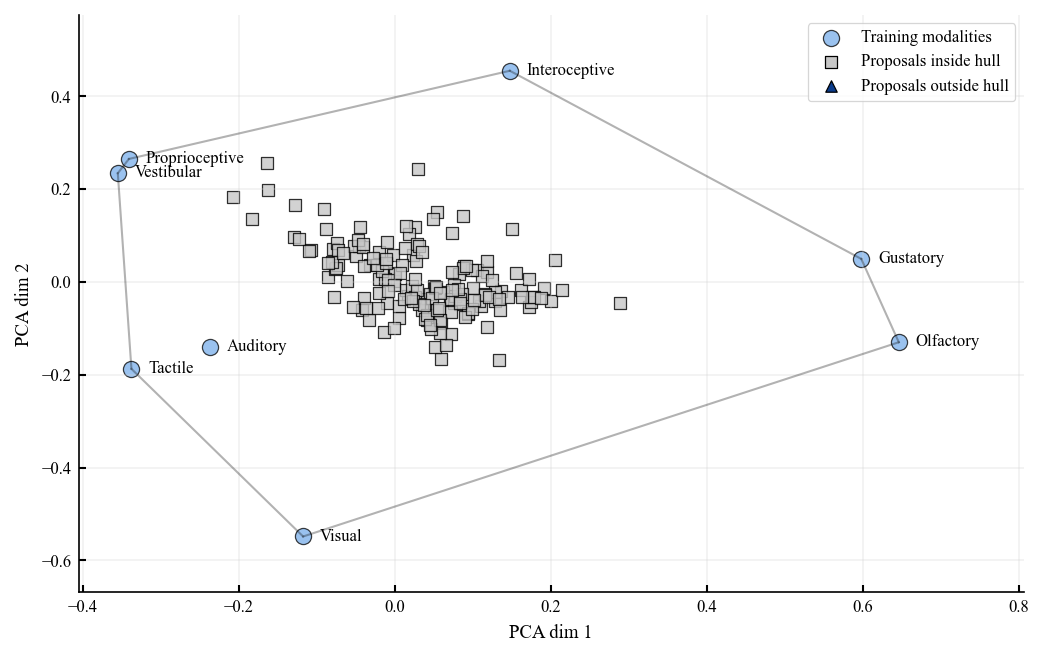

In [44]:
# 2D embedding space — hull membership based on 3D PCA
plot_embedding_space(
    training_emb_reduced=training_emb_reduced,
    proposal_emb_reduced=proposal_emb_reduced,
    modalities=modalities,
    inside_hull=inside_hull_3d,
    membership_label="3D PCA",
    save_path="results/test1/embedding_space_analysis.png",
)

In [45]:
def plot_embedding_space_3d(
    training_emb_reduced: np.ndarray,
    proposal_emb_reduced: np.ndarray,
    modalities: list[str],
    inside_hull_3d: np.ndarray,
    save_path: str,
) -> None:
    """True 3D PCA view with canonical 3D hull membership labels."""
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(111, projection="3d")

    training_z = training_emb_reduced[:, 2] if training_emb_reduced.shape[1] > 2 else np.zeros(len(training_emb_reduced))
    proposal_z = proposal_emb_reduced[:, 2] if proposal_emb_reduced.shape[1] > 2 else np.zeros(len(proposal_emb_reduced))

    ax.scatter(
        training_emb_reduced[:, 0],
        training_emb_reduced[:, 1],
        training_z,
        s=60,
        c=BLUE_GRAY_RAMP[2],
        marker="o",
        edgecolors="black",
        alpha=0.7,
        
        label="Training modalities",
    )

    for index, modality in enumerate(modalities):
        ax.text(
            training_emb_reduced[index, 0],
            training_emb_reduced[index, 1],
            training_z[index],
            _modality_label(modality),
            fontsize=8,
        )

    inside_mask = inside_hull_3d.astype(bool)
    ax.scatter(
        proposal_emb_reduced[inside_mask, 0],
        proposal_emb_reduced[inside_mask, 1],
        proposal_z[inside_mask],
        s=30,
        c=BLUE_GRAY_RAMP[4],
        marker="o",
        edgecolors="black",
        alpha=0.8,
        label="Proposals inside hull (3D PCA)",
    )

    if (~inside_mask).any():
        outside_mask = ~inside_mask
        ax.scatter(
            proposal_emb_reduced[outside_mask, 0],
            proposal_emb_reduced[outside_mask, 1],
            proposal_z[outside_mask],
            s=30,
            c=BLUE_GRAY_RAMP[0],
            marker="^",
            edgecolors="black",
            alpha=0.9,
            label="Proposals outside hull (3D PCA)",
        )

    ax.set_xlabel("PCA dim 1")
    ax.set_ylabel("PCA dim 2")
    ax.set_zlabel("PCA dim 3")
    # ax.set_title("3D Embedding Space: Training vs Proposals")

    # Reduce spine width for a refined look

    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.subplots_adjust(left=0.08, right=0.98)
    plt.savefig(save_path, bbox_inches="tight")
    print(f"Visualization saved to: {save_path}")
    plt.show()


Visualization saved to: results/test1/embedding_space_analysis_3d.png


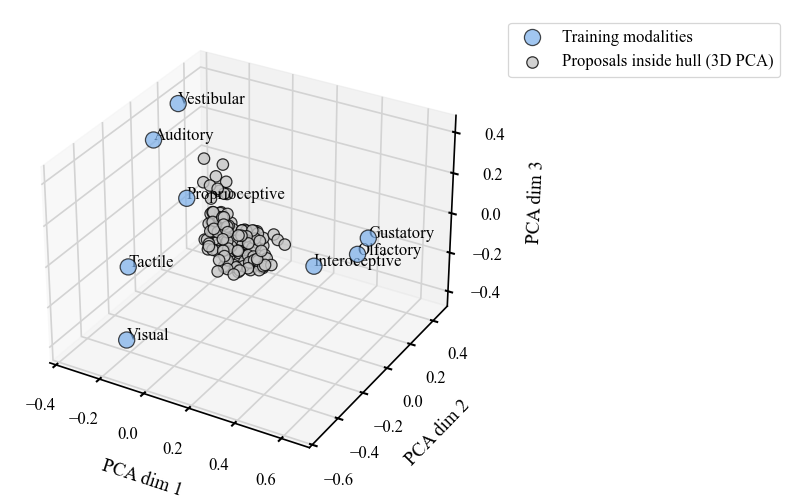

In [46]:
# 3D embedding space
plot_embedding_space_3d(
    training_emb_reduced=training_emb_reduced,
    proposal_emb_reduced=proposal_emb_reduced,
    modalities=modalities,
    inside_hull_3d=inside_hull_3d,
    save_path="results/test1/embedding_space_analysis_3d.png",
)

## 6. Comprehensive Classification of Proposals

### 6.1 Classification Rules and Summary Figures

Apply rule-based classification to Test 1 proposals and visualize class composition and novelty distributions.

In [47]:
test1_results = pd.read_csv(path_test1_results)

def _derive_novelty_proxy(df: pd.DataFrame) -> pd.Series:
    # Prefer explicit novelty score if available; otherwise use inverse similarity proxy.
    if "novelty_score" in df.columns:
        return pd.to_numeric(df["novelty_score"], errors="coerce")
    sim = pd.to_numeric(df.get("max_similarity", np.nan), errors="coerce")
    return (1.0 - sim).clip(lower=0.0, upper=1.0)

def classify_proposal(row: pd.Series) -> str:
    """Classify proposal as novel or traceable based on schema-robust criteria."""
    is_range_ext = bool(row.get("is_range_extension", row.get("is_extension", False)))
    is_hybrid = bool(row.get("is_hybrid", False))

    if "is_traceable" in row.index:
        is_traceable = bool(row.get("is_traceable", False))
    elif "lit_matches" in row.index:
        is_traceable = float(pd.to_numeric(row.get("lit_matches", 0), errors="coerce") or 0) > 0
    elif "is_novel" in row.index:
        is_traceable = str(row.get("is_novel", "")).upper() == "NO"
    else:
        # Legacy fallback
        is_traceable = str(row.get("ontologically_novel", "")).upper() == "NO"

    inside_hull = bool(row.get("inside_convex_hull", False))
    max_sim = float(pd.to_numeric(row.get("max_similarity", np.nan), errors="coerce"))
    novelty_score = float(pd.to_numeric(row.get("novelty_score_proxy", np.nan), errors="coerce"))

    if (
        not is_range_ext
        and not is_hybrid
        and not is_traceable
        and not inside_hull
        and np.isfinite(max_sim)
        and max_sim < 0.75
        and np.isfinite(novelty_score)
        and novelty_score > 0.7
    ):
        return "Genuinely Novel"
    if is_range_ext:
        return "Range Extension"
    if is_hybrid:
        return "Hybrid/Combination"
    if is_traceable:
        return "Literature Traceable"
    return "Recombination"

# Ensure supporting numeric fields exist
test1_results["novelty_score_proxy"] = _derive_novelty_proxy(test1_results)
if "inside_convex_hull" not in test1_results.columns:
    test1_results["inside_convex_hull"] = False

# Apply classification
test1_results["classification"] = test1_results.apply(classify_proposal, axis=1)

# Summary statistics
classification_counts = test1_results["classification"].value_counts()
print("\n=== FINAL CLASSIFICATION RESULTS ===")
print(classification_counts)
mask_gn = test1_results["classification"] == "Genuinely Novel"
print(
    f"\nGenuinely novel: {mask_gn.sum()} "
    f"({mask_gn.mean():.1%})"
)


=== FINAL CLASSIFICATION RESULTS ===
classification
Literature Traceable    85
Hybrid/Combination      48
Range Extension         34
Recombination            1
Name: count, dtype: int64

Genuinely novel: 0 (0.0%)


Classification summary visualization saved to: results/test1/classification_summary.png


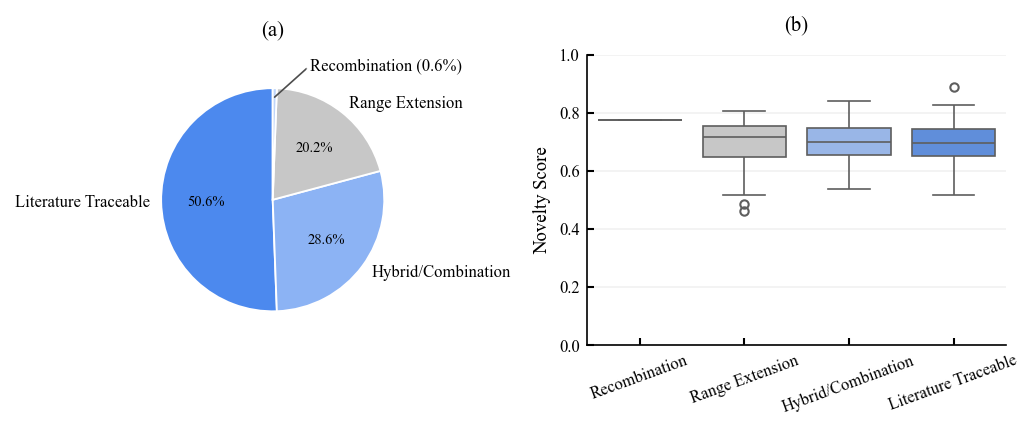

In [48]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(7, 3), gridspec_kw={"width_ratios": [1, 1.5]})

plot_df = test1_results.copy()
plot_df["novelty_for_plot"] = pd.to_numeric(plot_df["novelty_score_proxy"], errors="coerce")

class_order = (
    plot_df.groupby("classification")["novelty_for_plot"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Semantic color map: keys match classification label substrings.
_color_keys = {
    "Literature Traceable": WHITE_SKY_CMAP(0.70),
    "Hybrid/Combination":   WHITE_SKY_CMAP(0.45),
    "Recombination":        WHITE_SKY_CMAP(0.25),
    "Range Extension":      BLUE_GRAY_RAMP[4],
    "Genuinely Novel":      SKY_WHITE_GRAY_CMAP(0.72),
}
# Fallback for any label not explicitly mapped.
_fallback = [BLUE_GRAY_RAMP[i] for i in np.linspace(0, len(BLUE_GRAY_RAMP) - 1, len(class_order), dtype=int)]
palette_map = {lbl: _color_keys.get(lbl, _fallback[i]) for i, lbl in enumerate(class_order)}

pie_colors = [palette_map.get(lbl, BLUE_GRAY_RAMP[1]) for lbl in classification_counts.index]

wedges, texts, autotexts = axes[0].pie(
    classification_counts.values,
    labels=classification_counts.index,
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "#ffffff", "linewidth": 0.9},
)

plt.setp(texts, fontsize=8)
plt.setp(autotexts, fontsize=7)

# Add leader arrows only for very small slices (<3%).
total_count = float(np.sum(classification_counts.values))
for wedge, label_text, pct_text, raw_count in zip(wedges, texts, autotexts, classification_counts.values):
    pct = (100.0 * float(raw_count) / total_count) if total_count > 0 else 0.0
    if pct >= 3.0:
        continue

    # Hide default label/percent for tiny wedges and redraw with a leader line.
    label_text.set_visible(False)
    pct_text.set_visible(False)

    theta = np.deg2rad(0.5 * (wedge.theta1 + wedge.theta2))
    x, y = np.cos(theta), np.sin(theta)

    label_x = (1.28 * np.sign(x)) - 0.95
    label_y = 1.20 * y

    axes[0].annotate(
        f"{label_text.get_text()} ({pct:.1f}%)",
        xy=(0.92 * x, 0.92 * y),
        xytext=(label_x, label_y),
        ha="left" if x >= 0 else "right",
        va="center",
        fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "boxstyle": "round,pad=0.18"},
        arrowprops={
            "arrowstyle": "-",
            "lw": 0.8,
            "color": "#4d4d4d",
            "relpos": (0.0, 0.5),  # always connect to the left side of the label box
            "shrinkA": 0,
            "shrinkB": 0,
            "connectionstyle": "arc3,rad=0.0",
        },
    )

axes[0].set_title("(a)")

sns.boxplot(
    data=plot_df,
    x="classification",
    y="novelty_for_plot",
    order=class_order,
    hue="classification",
    hue_order=class_order,
    dodge=False,
    ax=axes[1],
    linewidth=0.8,
    palette=palette_map,
    showfliers=True,
    legend=False,
)

'''
sns.stripplot(
    data=plot_df,
    x="classification",
    y="novelty_for_plot",
    order=class_order,
    ax=axes[1],
    color=SKY_WHITE_GRAY_CMAP(0.95),
    alpha=0.7,
    jitter=0.22,
    size=3,
)
'''
axes[1].set_ylabel("Novelty Score")
axes[1].set_xlabel("")
axes[1].set_title("(b)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("results/test1/classification_summary.png", bbox_inches="tight")
print("Classification summary visualization saved to: results/test1/classification_summary.png")
plt.show()


**Figure caption.** **(a)** Classification of AI proposals into traceable, hybrid, and novel categories. **(b)** Distribution of continuous novelty scores by classification group; dashed line marks the novelty threshold.

### 6.1b Calibrated Distance-to-Novelty Metrics

`1 - max_similarity` can be misleading on its own. This block calibrates novelty against the **known modality manifold** and reports how far each proposal is from a conservative novelty boundary.

In [49]:
# Calibrated novelty-distance metrics against known modalities.
if "training_embeddings" not in globals() or "proposal_embeddings" not in globals():
    raise RuntimeError(
        "Run the embedding cell in Section 4 first so training_embeddings and proposal_embeddings exist."
    )

if "test1_results" not in globals() or not isinstance(test1_results, pd.DataFrame):
    test1_results = pd.read_csv(path_test1_results)

# Similarity among known modalities (leave-one-out max similarity baseline).
sim_train_train = cosine_similarity(training_embeddings)
np.fill_diagonal(sim_train_train, -np.inf)
ref_max_sim = sim_train_train.max(axis=1)
ref_mean = float(np.mean(ref_max_sim))
ref_std = float(np.std(ref_max_sim, ddof=0))
q05 = float(np.quantile(ref_max_sim, 0.05))
q01 = float(np.quantile(ref_max_sim, 0.01))

# Proposal to known-modality similarities.
sim_prop_train = cosine_similarity(proposal_embeddings, training_embeddings)
prop_max_sim = sim_prop_train.max(axis=1)
prop_nn_dist = 1.0 - prop_max_sim

# Distance from conservative novelty boundaries.
# Positive gap => beyond the novelty boundary (more novel); negative => still inside known range.
gap_to_q05 = q05 - prop_max_sim
gap_to_q01 = q01 - prop_max_sim

# Empirical lower-tail probability under known-known baseline.
# Low p_tail means proposal similarity is unusually low relative to known modalities.
# Add +1 smoothing to avoid exact zero with small baseline size (n=8).
p_tail = np.array([(np.sum(ref_max_sim <= s) + 1) / (len(ref_max_sim) + 1) for s in prop_max_sim])

# Hull-violation magnitude (0 for inside hull).
if "outside_violation" in globals() and len(outside_violation) == len(test1_results):
    hull_violation = np.asarray(outside_violation, dtype=float)
elif "training_hull" in globals() and "proposal_emb_reduced" in globals():
    A = training_hull.equations[:, :-1]
    b = training_hull.equations[:, -1]
    vals = proposal_emb_reduced @ A.T + b
    hull_violation = np.maximum(vals, 0.0).max(axis=1)
else:
    hull_violation = np.zeros(len(test1_results), dtype=float)

# Merge into analysis table.
novelty_distance_df = test1_results.copy()
novelty_distance_df["prop_max_similarity"] = prop_max_sim
novelty_distance_df["prop_nn_distance"] = prop_nn_dist
novelty_distance_df["novelty_gap_q05"] = gap_to_q05
novelty_distance_df["novelty_gap_q01"] = gap_to_q01
novelty_distance_df["novelty_tail_p"] = p_tail
novelty_distance_df["hull_violation"] = hull_violation
novelty_distance_df["beyond_q05"] = novelty_distance_df["novelty_gap_q05"] > 0
novelty_distance_df["beyond_q01"] = novelty_distance_df["novelty_gap_q01"] > 0

# Optional composite distance score (rank-based, robust to scale mismatch).
rank_nn = novelty_distance_df["prop_nn_distance"].rank(pct=True)
rank_gap = novelty_distance_df["novelty_gap_q05"].rank(pct=True)
rank_hull = novelty_distance_df["hull_violation"].rank(pct=True)
novelty_distance_df["novelty_distance_score"] = (0.45 * rank_nn + 0.35 * rank_gap + 0.20 * rank_hull)

print("=== Calibrated Novelty Distance Summary ===")
print(f"Known-known max similarity baseline (n={len(ref_max_sim)}):")
print(f"  mean={ref_mean:.3f}, std={ref_std:.3f}, q05={q05:.3f}, q01={q01:.3f}")
print(f"Proposals beyond q05 novelty boundary: {novelty_distance_df['beyond_q05'].sum()} / {len(novelty_distance_df)}")
print(f"Proposals beyond q01 novelty boundary: {novelty_distance_df['beyond_q01'].sum()} / {len(novelty_distance_df)}")
print(f"Median novelty gap to q05: {novelty_distance_df['novelty_gap_q05'].median():.3f}")
print(f"Median lower-tail p-value: {novelty_distance_df['novelty_tail_p'].median():.3f}")

name_col = "proposal_name" if "proposal_name" in novelty_distance_df.columns else "closest_modality"
summary_cols = [
    c for c in [
        "model", "proposal_id", name_col,
        "prop_max_similarity", "prop_nn_distance", "novelty_gap_q05",
        "novelty_tail_p", "hull_violation", "novelty_distance_score",
        "beyond_q05", "beyond_q01",
    ] if c in novelty_distance_df.columns
]

print("\nTop-10 farthest from known manifold (higher novelty distance):")
display(
    novelty_distance_df[summary_cols]
    .sort_values(["novelty_distance_score", "novelty_gap_q05"], ascending=False)
    .head(10)
)

novelty_distance_out = Path("results/test1/novelty_distance_metrics.csv")
novelty_distance_df.to_csv(novelty_distance_out, index=False)
print(f"Saved calibrated metrics: {novelty_distance_out}")

=== Calibrated Novelty Distance Summary ===
Known-known max similarity baseline (n=8):
  mean=0.605, std=0.064, q05=0.507, q01=0.477
Proposals beyond q05 novelty boundary: 166 / 168
Proposals beyond q01 novelty boundary: 164 / 168
Median novelty gap to q05: 0.208
Median lower-tail p-value: 0.111

Top-10 farthest from known manifold (higher novelty distance):


,model,proposal_id,proposal_name,prop_max_similarity,prop_nn_distance,novelty_gap_q05,novelty_tail_p,hull_violation,novelty_distance_score,beyond_q05,beyond_q01
128,perplexity-sonar-pro,sample_128,Chronoreceptive Modality,0.110932,0.889068,0.396499,0.111111,0.0,0.900595,True,True
15,gemini-3.1-pro-preview,sample_015,Entropoception,0.159238,0.840762,0.348193,0.111111,0.0,0.895833,True,True
9,gemini-3.1-pro-preview,sample_009,Entropiception,0.166139,0.833861,0.341293,0.111111,0.0,0.891071,True,True
63,claude-3.7-sonnet,sample_063,Chronoception,0.173753,0.826247,0.333678,0.111111,0.0,0.886310,True,True
108,gemini-3.1-pro-preview,sample_108,Stochastiception,0.185689,0.814311,0.321742,0.111111,0.0,0.881548,True,True
96,gemini-3.1-pro-preview,sample_096,Entropoception,0.188815,0.811185,0.318616,0.111111,0.0,0.876786,True,True
89,claude-3.7-sonnet,sample_089,Chronoception,0.189762,0.810238,0.317670,0.111111,0.0,0.872024,True,True
118,gemini-3.1-pro-preview,sample_118,Entropioception,0.190553,0.809447,0.316879,0.111111,0.0,0.867262,True,True
92,claude-3.7-sonnet,sample_092,Chronoception,0.193066,0.806934,0.314366,0.111111,0.0,0.862500,True,True
151,gemini-3.1-pro-preview,sample_151,Entropiception,0.194133,0.805867,0.313298,0.111111,0.0,0.857738,True,True


Saved calibrated metrics: results/test1/novelty_distance_metrics.csv


Saved Frontier Bands by Model to: results/test1/novelty_frontier_bands_by_model.png
Saved Continuous Novelty Score Histogram to: results/test1/continuous_novelty_score_histogram.png


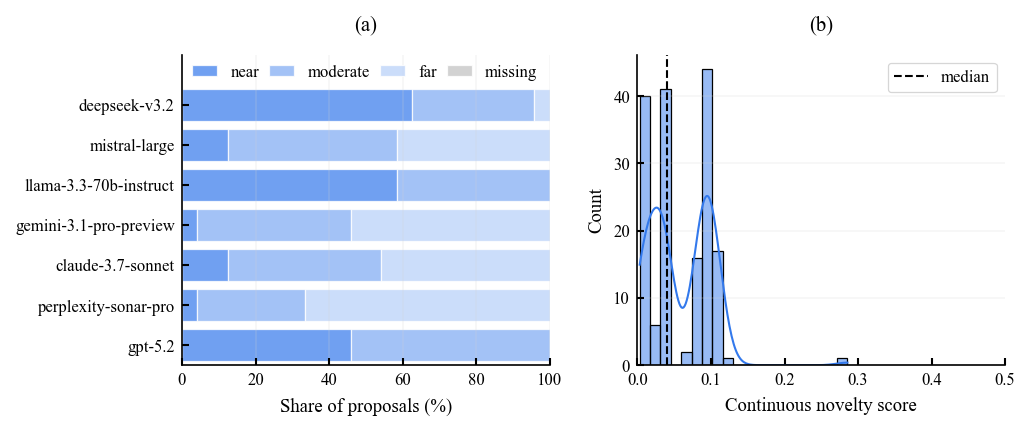

In [50]:
# Figure 2 + Figure 3 combined: parallel subplots (1 row, 2 columns).
# Make this cell robust when run independently.
if "dash_df" not in globals() or not isinstance(dash_df, pd.DataFrame):
    if "rule_df" in globals() and isinstance(rule_df, pd.DataFrame):
        dash_df = rule_df.copy()
    elif "novelty_distance_df" in globals() and isinstance(novelty_distance_df, pd.DataFrame):
        dash_df = novelty_distance_df.copy()
    elif "test1_results" in globals() and isinstance(test1_results, pd.DataFrame):
        dash_df = test1_results.copy()
    else:
        raise RuntimeError(
            "No source DataFrame found. Run Section 6.1b (and preferably 6.2) before this cell."
        )

if "model" not in dash_df.columns:
    dash_df["model"] = "unknown"
dash_df["model"] = dash_df["model"].astype(str)

# Build frontier bands if they are not already available.
if "frontier_band" not in dash_df.columns:
    distance_col = next(
        (col for col in ["novelty_frontier_distance", "novelty_distance_score"] if col in dash_df.columns),
        None,
    )
    if distance_col is None:
        raise KeyError(
            "Missing frontier metric. Expected one of: novelty_frontier_distance, novelty_distance_score."
        )

    dash_df[distance_col] = pd.to_numeric(dash_df[distance_col], errors="coerce")

    # Thresholds depend on metric scale.
    if distance_col == "novelty_distance_score":
        def _band_from_distance(x: float) -> str:
            if not np.isfinite(x):
                return "missing"
            if x <= 0.33:
                return "near"
            if x <= 0.66:
                return "moderate"
            return "far"
    else:
        def _band_from_distance(x: float) -> str:
            if not np.isfinite(x):
                return "missing"
            if x <= 1.0:
                return "near"
            if x <= 2.0:
                return "moderate"
            return "far"

    dash_df["frontier_band"] = dash_df[distance_col].apply(_band_from_distance)

if "model_order" not in globals() or not isinstance(model_order, list) or len(model_order) == 0:
    model_order = dash_df["model"].value_counts().index.tolist()

out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)

band_order = ["near", "moderate", "far", "missing"]
band_ct = pd.crosstab(dash_df["model"], dash_df["frontier_band"]).reindex(model_order).fillna(0)
for b in band_order:
    if b not in band_ct.columns:
        band_ct[b] = 0
band_ct = band_ct[band_order]
band_pct = band_ct.div(band_ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100.0

fig23, (ax2, ax3) = plt.subplots(1, 2, figsize=(7, 3), gridspec_kw={"width_ratios": [1.0, 1.0]})

# Same colormap logic as recent figures: blue intensity + gray for missing.
colors = {
    "near": WHITE_SKY_CMAP(0.70),
    "moderate": WHITE_SKY_CMAP(0.45),
    "far": WHITE_SKY_CMAP(0.25),
    "missing": BLUE_GRAY_RAMP[4],
}

# Left panel: stacked frontier bands by model.
y_pos = np.arange(len(band_pct))
left = np.zeros(len(band_pct))
for b in band_order:
    vals = band_pct[b].to_numpy()
    ax2.barh(
        y_pos,
        vals,
        left=left,
        color=colors[b],
        label=b,
        alpha=0.8,
        edgecolor="#ffffff",
    )
    left += vals

ax2.set_yticks(y_pos)
ax2.set_yticklabels(band_pct.index)
ax2.invert_yaxis()
# Reserve vertical room INSIDE the left subplot for the legend so bars stay unobstructed.
ax2.set_ylim(len(y_pos) - 0.5, -1.25)

ax2.set_xlim(0, 100)
ax2.set_xlabel("Share of proposals (%)")
ax2.set_ylabel("")
ax2.set_title("(a)")
ax2.grid(axis="x", alpha=0.2)

# Keep legend inside the left subplot so combined left content matches right subplot height.
ax2.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=4,
    borderaxespad=0.0,
    frameon=False,
    handlelength=1.5,
    columnspacing=0.6,
)

# Right panel: continuous novelty score distribution.
score_hist_png = None
if "continuous_novelty_score" in dash_df.columns and dash_df["continuous_novelty_score"].notna().any():
    sns.histplot(
        data=dash_df,
        x="continuous_novelty_score",
        bins=20,
        kde=True,
        color=WHITE_SKY_CMAP(0.8),
        ax=ax3,
    )
    ax3.axvline(
        float(dash_df["continuous_novelty_score"].median()),
        color='k',
        linestyle="--",
        label="median",
    )
    ax3.set_xlim(0, 0.5)
    ax3.set_xlabel("Continuous novelty score")
    ax3.set_ylabel("Count")
    ax3.legend(loc="upper right")
    ax3.set_title("(b)")
    ax3.grid(axis="y", alpha=0.2)
else:
    ax3.text(0.5, 0.5, "Continuous novelty score not available", ha="center", va="center")
    ax3.set_xlabel("Continuous novelty score")
    ax3.set_ylabel("Count")

plt.tight_layout()

bands_png = out_dir / "novelty_frontier_bands_by_model.png"
score_hist_png = out_dir / "continuous_novelty_score_histogram.png"
plt.savefig(bands_png, bbox_inches="tight")
print(f"Saved Frontier Bands by Model to: {bands_png}")
plt.savefig(score_hist_png, bbox_inches="tight")
print(f"Saved Continuous Novelty Score Histogram to: {score_hist_png}")
plt.show()

**Figure caption.** **(a)** Frontier-distance severity by model, showing each model's mean distance to the novelty decision boundary. **(b)** Continuous novelty score distribution across all proposals, highlighting concentration in the low-novelty regime.

In [51]:
# Export compact summary table for the paper text.
distance_col = next(
    (
        column
        for column in ["novelty_frontier_distance", "novelty_distance_score"]
        if column in dash_df.columns
    ),
    None,
)
if distance_col is None:
    raise KeyError("No distance column found in dash_df.")

summary_rows = []
for m in model_order:
    g = dash_df[dash_df["model"] == m]
    distance_series = pd.to_numeric(g[distance_col], errors="coerce")
    summary_rows.append(
        {
            "model": m,
            "n": int(len(g)),
            "frontier_distance_mean": float(distance_series.mean()),
            "frontier_distance_median": float(distance_series.median()),
            "continuous_novelty_score_mean": float(pd.to_numeric(g.get("continuous_novelty_score", np.nan), errors="coerce").mean()),
            "continuous_novelty_score_median": float(pd.to_numeric(g.get("continuous_novelty_score", np.nan), errors="coerce").median()),
            "gap_q05_median": float(pd.to_numeric(g.get("novelty_gap_q05", np.nan), errors="coerce").median()),
            "blocked_traceability_pct": float(g["violates_traceability"].mean() * 100.0) if "violates_traceability" in g else np.nan,
            "blocked_hull_pct": float(g["violates_hull"].mean() * 100.0) if "violates_hull" in g else np.nan,
            "blocked_hybrid_pct": float(g["violates_hybrid"].mean() * 100.0) if "violates_hybrid" in g else np.nan,
            "blocked_extension_pct": float(g["violates_extension"].mean() * 100.0) if "violates_extension" in g else np.nan,
        }
    )

novelty_dashboard_summary = pd.DataFrame(summary_rows)
summary_csv = out_dir / "novelty_distance_dashboard_summary_by_model.csv"
novelty_dashboard_summary.to_csv(summary_csv, index=False)

print("Saved novelty dashboard outputs:")
if "dashboard_png" in globals() and dashboard_png is not None:
    print(f" - {dashboard_png}")
print(f" - {bands_png}")
if score_hist_png is not None:
    print(f" - {score_hist_png}")
print(f" - {summary_csv}")
display(novelty_dashboard_summary)


Saved novelty dashboard outputs:
 - results/test1/novelty_frontier_bands_by_model.png
 - results/test1/continuous_novelty_score_histogram.png
 - results/test1/novelty_distance_dashboard_summary_by_model.csv


,model,n,frontier_distance_mean,frontier_distance_median,continuous_novelty_score_mean,continuous_novelty_score_median,gap_q05_median,blocked_traceability_pct,blocked_hull_pct,blocked_hybrid_pct,blocked_extension_pct
0,deepseek-v3.2,24,0.334127,0.300595,0.063336,0.085267,0.156745,NaN,NaN,NaN,NaN
1,mistral-large,24,0.558929,0.557738,0.072111,0.089635,0.224648,NaN,NaN,NaN,NaN
2,llama-3.3-70b-instruct,24,0.317460,0.286310,0.081541,0.087286,0.152390,NaN,NaN,NaN,NaN
3,gemini-3.1-pro-preview,24,0.660119,0.679167,0.077642,0.089385,0.250624,NaN,NaN,NaN,NaN
4,claude-3.7-sonnet,24,0.607540,0.624405,0.070435,0.092967,0.238298,NaN,NaN,NaN,NaN
5,perplexity-sonar-pro,24,0.685516,0.726786,0.034719,0.031606,0.261619,NaN,NaN,NaN,NaN
6,gpt-5.2,24,0.357143,0.376786,0.013507,0.010544,0.175918,NaN,NaN,NaN,NaN


### 6.1c.1 Continuous Novelty Score by Model

Add a compact model-level view of `continuous_novelty_score` and generate a short manuscript-ready interpretation paragraph based on the latest values.

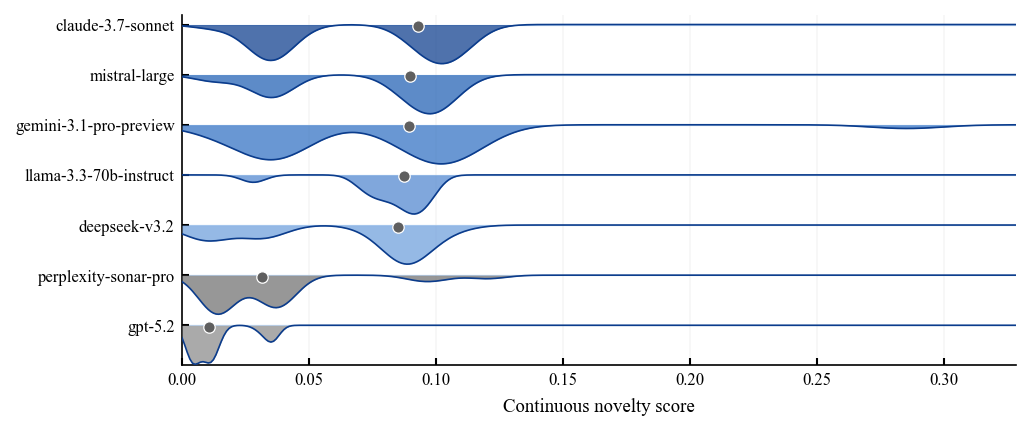

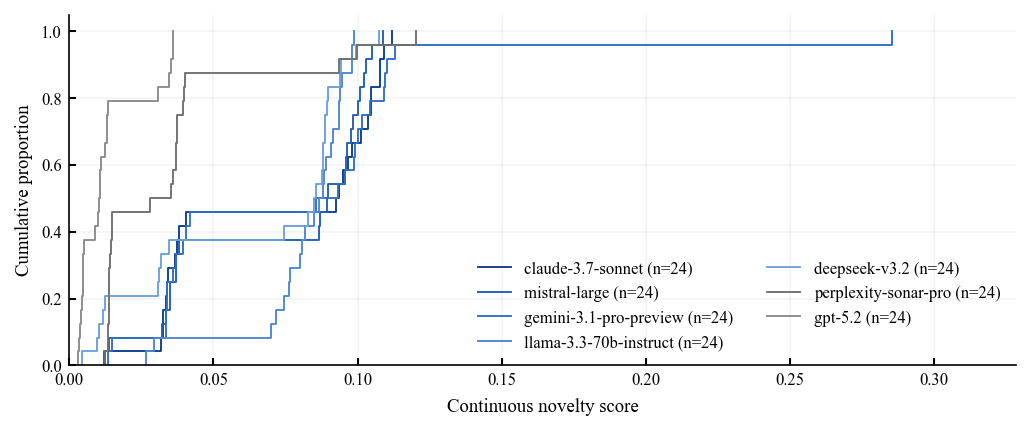

Saved ridgeline score plot: results/test1/continuous_novelty_score_by_model_ridgeline.png
Saved ECDF score plot: results/test1/continuous_novelty_score_by_model_ecdf.png
Saved interpretation paragraph: results/test1/continuous_novelty_score_paragraph.txt

=== Continuous Novelty Score Interpretation ===
The continuous novelty score remained low overall, with a median of 0.040 and mean of 0.059, indicating that most Test 1 proposals stayed far from the study's effective novelty boundary even when semantic distance from known modalities was non-zero. At the model level, claude-3.7-sonnet showed the highest median continuous novelty score (0.093), whereas gpt-5.2 showed the lowest (0.011). This pattern is consistent with the frontier analysis: differences across models exist, but all models remain heavily constrained by structural blockers such as hull membership and traceability.


,model,mean,median,std,count
0,claude-3.7-sonnet,0.0704,0.0930,0.0357,24
1,mistral-large,0.0721,0.0896,0.0339,24
2,gemini-3.1-pro-preview,0.0776,0.0894,0.0568,24
3,llama-3.3-70b-instruct,0.0815,0.0873,0.0185,24
4,deepseek-v3.2,0.0633,0.0853,0.0358,24
5,perplexity-sonar-pro,0.0347,0.0316,0.0295,24
6,gpt-5.2,0.0135,0.0105,0.0115,24


In [52]:
# Model-level view of the continuous novelty score plus a compact interpretation paragraph.
from scipy.stats import gaussian_kde

if "dash_df" not in globals() or not isinstance(dash_df, pd.DataFrame):
    if "rule_df" in globals() and isinstance(rule_df, pd.DataFrame):
        dash_df = rule_df.copy()
    elif "novelty_distance_df" in globals() and isinstance(novelty_distance_df, pd.DataFrame):
        dash_df = novelty_distance_df.copy()
    else:
        raise RuntimeError("Run the frontier-distance cell first so dash_df, rule_df, or novelty_distance_df exists.")

plot_score_df = dash_df.copy()
if "continuous_novelty_score" not in plot_score_df.columns:
    raise KeyError("continuous_novelty_score is missing. Run the frontier-distance cell first.")

plot_score_df["continuous_novelty_score"] = pd.to_numeric(
    plot_score_df["continuous_novelty_score"], errors="coerce"
).clip(lower=0.0, upper=1.0)
plot_score_df = plot_score_df.dropna(subset=["continuous_novelty_score"]).copy()

if "model" not in plot_score_df.columns:
    plot_score_df["model"] = "unknown"
plot_score_df["model"] = plot_score_df["model"].astype(str)

model_order_score = (
    plot_score_df.groupby("model")["continuous_novelty_score"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Use a data-driven x-range so the diagnostics focus on the observed score mass.
score_max = float(plot_score_df["continuous_novelty_score"].max()) if len(plot_score_df) else 1.0
x_max = min(1.0, max(0.20, score_max * 1.15))

palette_score = MODEL_VISIBLE_COLORS[:len(model_order_score)]
x_grid = np.linspace(0, x_max, 320)

# Figure 1: ridgeline density by model.
fig_dist, ax_dist = plt.subplots(figsize=(7, 3))
for i, model_name in enumerate(model_order_score):
    vals = plot_score_df.loc[plot_score_df["model"] == model_name, "continuous_novelty_score"].dropna()
    n_vals = len(vals)

    if n_vals == 0:
        continue

    if n_vals >= 2 and vals.nunique() > 1:
        kde = gaussian_kde(vals.to_numpy(), bw_method=0.25)
        dens = kde(x_grid)
    else:
        center = float(vals.iloc[0])
        dens = np.exp(-0.5 * ((x_grid - center) / 0.02) ** 2)

    max_d = float(np.max(dens)) if len(dens) else 0.0
    dens_norm = dens / max_d if max_d > 0 else dens
    ridge_height = 0.78
    ridge_y = i + ridge_height * dens_norm

    ax_dist.fill_between(
        x_grid,
        i,
        ridge_y,
        color=palette_score[i],
        alpha=0.72,
        linewidth=0,
        zorder=2 + i,
    )
    ax_dist.plot(x_grid, ridge_y, color=BLUE_GRAY_RAMP[0], linewidth=0.8, zorder=3 + i)
    ax_dist.hlines(i, 0, x_max, color=BLUE_GRAY_RAMP[2], linewidth=0.6, alpha=0.45, zorder=1)

    med = float(vals.median())
    ax_dist.scatter(
        med,
        i + 0.03,
        color=THRESHOLD_COLOR,
        edgecolor="white",
        linewidth=0.6,
        s=30,
        zorder=10,
    )

#ax_dist.set_title("Continuous Novelty by Model")
#ax_dist.set_ylabel("Model")
ax_dist.set_xlabel("Continuous novelty score")
ax_dist.set_xlim(0, x_max)
ax_dist.set_ylim(-0.2, max(len(model_order_score) - 0.2, 0.8))
ax_dist.set_yticks(range(len(model_order_score)))
ax_dist.set_yticklabels([f"{m}" for m in model_order_score])
ax_dist.grid(axis="x", alpha=0.2)
ax_dist.invert_yaxis()

# Figure 2: ECDF by model.
fig_ecdf, ax_ecdf = plt.subplots(figsize=(7, 3))
for i, model_name in enumerate(model_order_score):
    vals = plot_score_df.loc[plot_score_df["model"] == model_name, "continuous_novelty_score"].dropna()
    if len(vals) == 0:
        continue
    sns.ecdfplot(
        vals,
        ax=ax_ecdf,
        color=palette_score[i],
        linewidth=0.9,
        label=f"{model_name} (n={len(vals)})",
    )

#ax_ecdf.set_title("Continuous Novelty Score ECDF by Model")
ax_ecdf.set_xlabel("Continuous novelty score")
ax_ecdf.set_ylabel("Cumulative proportion")
ax_ecdf.set_xlim(0, x_max)
ax_ecdf.set_ylim(0, 1.05)
ax_ecdf.grid(alpha=0.25)
ax_ecdf.legend(loc="lower right", frameon=False, ncol=2)

out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
score_by_model_ridgeline_png = out_dir / "continuous_novelty_score_by_model_ridgeline.png"
score_by_model_ecdf_png = out_dir / "continuous_novelty_score_by_model_ecdf.png"
fig_dist.tight_layout()
fig_dist.savefig(score_by_model_ridgeline_png, bbox_inches="tight")
fig_ecdf.tight_layout()
fig_ecdf.savefig(score_by_model_ecdf_png, bbox_inches="tight")
plt.show(fig_dist)
plt.show(fig_ecdf)

score_summary = (
    plot_score_df.groupby("model")["continuous_novelty_score"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("median", ascending=False)
    .reset_index()
)

top_model = score_summary.iloc[0]
bottom_model = score_summary.iloc[-1]
overall_median = float(plot_score_df["continuous_novelty_score"].median())
overall_mean = float(plot_score_df["continuous_novelty_score"].mean())

interpretation_text = (
    "The continuous novelty score remained low overall, with a median of "
    f"{overall_median:.3f} and mean of {overall_mean:.3f}, indicating that most Test 1 proposals stayed far from the study's "
    "effective novelty boundary even when semantic distance from known modalities was non-zero. "
    f"At the model level, {top_model['model']} showed the highest median continuous novelty score "
    f"({top_model['median']:.3f}), whereas {bottom_model['model']} showed the lowest ({bottom_model['median']:.3f}). "
    "This pattern is consistent with the frontier analysis: differences across models exist, but all models remain heavily "
    "constrained by structural blockers such as hull membership and traceability."
)

text_path = out_dir / "continuous_novelty_score_paragraph.txt"
with text_path.open("w", encoding="utf-8") as f:
    f.write(interpretation_text + "\n")

print(f"Saved ridgeline score plot: {score_by_model_ridgeline_png}")
print(f"Saved ECDF score plot: {score_by_model_ecdf_png}")
print(f"Saved interpretation paragraph: {text_path}")
print("\n=== Continuous Novelty Score Interpretation ===")
print(interpretation_text)
display(score_summary.round(4))


**Figure caption.** Continuous novelty score distributions by model. *(Top)* Ridgeline kernel-density plot with median markers (orange dots). *(Bottom)* Empirical CDF (ECDF) by model; dashed reference line at 0.5. Both panels share the same score axis and model color palette.

### 6.1d Frontier Distance Decomposition by Criterion

Decompose `novelty_frontier_distance` into additive components to quantify which criteria drive non-novel decisions for each model.

Max reconstruction delta vs novelty_frontier_distance: 0.000e+00


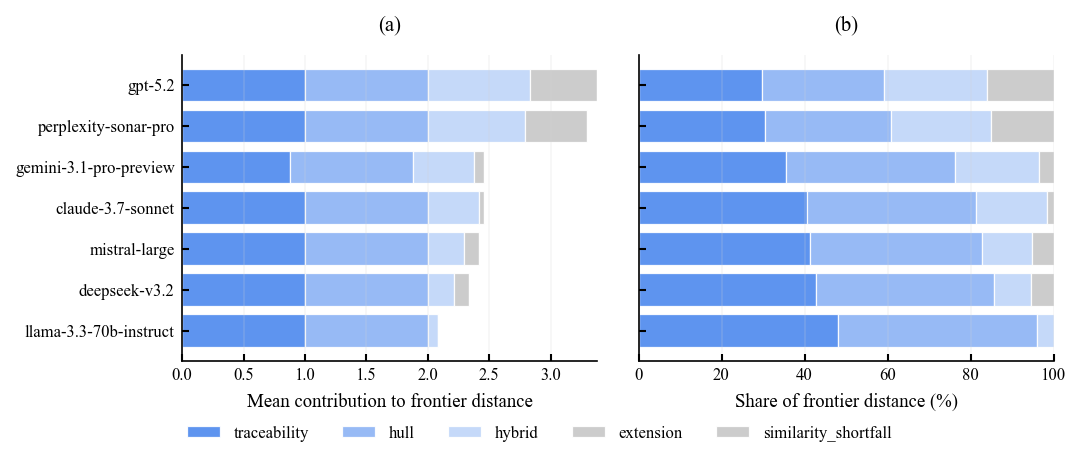

Saved decomposition outputs:
 - results/test1/novelty_frontier_decomposition_by_model_combined.png
 - results/test1/novelty_frontier_contribution_by_model.csv


,model,abs_traceability,abs_hull,abs_hybrid,abs_extension,abs_similarity_shortfall,pct_traceability,pct_hull,pct_hybrid,pct_extension,pct_similarity_shortfall
0,gpt-5.2,1.000,1.0,0.833333,0.541667,0.0,29.629630,29.629630,24.691358,16.049383,0.0
1,perplexity-sonar-pro,1.000,1.0,0.791667,0.500000,0.0,30.379747,30.379747,24.050633,15.189873,0.0
2,gemini-3.1-pro-preview,0.875,1.0,0.500000,0.083333,0.0,35.593220,40.677966,20.338983,3.389831,0.0
3,claude-3.7-sonnet,1.000,1.0,0.416667,0.041667,0.0,40.677966,40.677966,16.949153,1.694915,0.0
4,mistral-large,1.000,1.0,0.291667,0.125000,0.0,41.379310,41.379310,12.068966,5.172414,0.0
5,deepseek-v3.2,1.000,1.0,0.208333,0.125000,0.0,42.857143,42.857143,8.928571,5.357143,0.0
6,llama-3.3-70b-instruct,1.000,1.0,0.083333,0.000000,0.0,48.000000,48.000000,4.000000,0.000000,0.0


In [53]:
# Decompose novelty frontier distance into additive criterion components.
if "rule_df" in globals() and isinstance(rule_df, pd.DataFrame):
    decomp_df = rule_df.copy()
elif "novelty_distance_df" in globals() and isinstance(novelty_distance_df, pd.DataFrame):
    decomp_df = novelty_distance_df.copy()
else:
    raise RuntimeError("Run the frontier-distance cell first to create rule_df or novelty_distance_df.")

if "model" not in decomp_df.columns:
    decomp_df["model"] = "unknown"
decomp_df["model"] = decomp_df["model"].astype(str)

# Rebuild component terms exactly as used in novelty_frontier_distance.
sim_threshold = NOVELTY_FRONTIER_SIM_THRESHOLD
max_sim = pd.to_numeric(decomp_df.get("max_similarity", np.nan), errors="coerce")
if max_sim.isna().all() and "prop_max_similarity" in decomp_df.columns:
    max_sim = pd.to_numeric(decomp_df["prop_max_similarity"], errors="coerce")
sim_margin = sim_threshold - max_sim
sim_shortfall_component = np.maximum(0.0, -sim_margin) / sim_threshold

decomp_df["comp_similarity_shortfall"] = sim_shortfall_component

def _bool_component(col: str) -> pd.Series:
    if col in decomp_df.columns:
        return decomp_df[col].fillna(False).astype(bool).astype(float)
    return pd.Series(np.zeros(len(decomp_df)), index=decomp_df.index, dtype=float)

decomp_df["comp_traceability"] = _bool_component("is_traceable")
decomp_df["comp_hull"] = _bool_component("inside_convex_hull")
decomp_df["comp_hybrid"] = _bool_component("is_hybrid")
decomp_df["comp_extension"] = _bool_component("is_extension")

component_cols = [
    "comp_traceability",
    "comp_hull",
    "comp_hybrid",
    "comp_extension",
    "comp_similarity_shortfall",
]

# Consistency check with previously computed novelty_frontier_distance.
decomp_df["frontier_distance_rebuilt"] = decomp_df[component_cols].sum(axis=1)
if "novelty_frontier_distance" in decomp_df.columns:
    max_delta = float(np.nanmax(np.abs(decomp_df["frontier_distance_rebuilt"] - decomp_df["novelty_frontier_distance"])))
    print(f"Max reconstruction delta vs novelty_frontier_distance: {max_delta:.3e}")

# Per-model mean contribution (absolute units in frontier-distance points).
contrib_abs = decomp_df.groupby("model")[component_cols].mean()
contrib_pct = contrib_abs.div(contrib_abs.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0) * 100.0

# Order models by total mean distance for a more interpretable display.
model_order = contrib_abs.sum(axis=1).sort_values(ascending=False).index.tolist()
contrib_abs = contrib_abs.reindex(model_order)
contrib_pct = contrib_pct.reindex(model_order)

# Human-readable output table.
rename_map = {
    "comp_traceability": "traceability",
    "comp_hull": "hull",
    "comp_hybrid": "hybrid",
    "comp_extension": "extension",
    "comp_similarity_shortfall": "similarity_shortfall",
}
contrib_abs_disp = contrib_abs.rename(columns=rename_map)
contrib_pct_disp = contrib_pct.rename(columns=rename_map)

decomposition_table = contrib_abs_disp.add_prefix("abs_")
for column in contrib_pct_disp.columns:
    decomposition_table[f"pct_{column}"] = contrib_pct_disp[column]

decomposition_table = decomposition_table.reset_index()

plot_order = ["traceability", "hull", "hybrid", "extension", "similarity_shortfall"]
# Reuse the same blue/gray family as the frontier stacked bars.
colors = {
    "traceability": WHITE_SKY_CMAP(0.70),
    "hull": WHITE_SKY_CMAP(0.45),
    "hybrid": WHITE_SKY_CMAP(0.25),
    "extension": BLUE_GRAY_RAMP[4],
    "similarity_shortfall": SKY_WHITE_GRAY_CMAP(0.72),
}

# Keep both bar panels on the same row.
fig, (ax_abs, ax_pct) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

y_labels = contrib_abs_disp.index.tolist()
left_abs = np.zeros(len(contrib_abs_disp))
legend_handles = []
legend_labels = []
for key in plot_order:
    values = contrib_abs_disp[key].to_numpy() if key in contrib_abs_disp.columns else np.zeros(len(contrib_abs_disp))
    bars = ax_abs.barh(
        y_labels,
        values,
        left=left_abs,
        color=colors.get(key, "#999999"),
        alpha=0.90,
        edgecolor="white",
        linewidth=0.6,
        label=key,
    )
    left_abs += values
    legend_handles.append(bars[0])
    legend_labels.append(key)

ax_abs.set_xlabel("Mean contribution to frontier distance")
ax_abs.set_ylabel("")
ax_abs.set_title("(a)")
ax_abs.grid(axis="x", alpha=0.2)
ax_abs.invert_yaxis()

left_pct = np.zeros(len(contrib_pct_disp))
y_labels_pct = contrib_pct_disp.index.tolist()
for key in plot_order:
    values = contrib_pct_disp[key].to_numpy() if key in contrib_pct_disp.columns else np.zeros(len(contrib_pct_disp))
    ax_pct.barh(
        y_labels_pct,
        values,
        left=left_pct,
        color=colors.get(key, "#999999"),
        alpha=0.90,
        edgecolor="white",
    )
    left_pct += values

ax_pct.set_xlim(0, 100)
ax_pct.set_xlabel("Share of frontier distance (%)")
ax_pct.set_title("(b)")
ax_pct.grid(axis="x", alpha=0.2)
ax_pct.tick_params(axis="y", labelleft=False)

#fig.suptitle("Frontier Distance Decomposition by Criterion", y=0.98)
fig.legend(
    legend_handles,
    legend_labels,
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=5,
    frameon=False,
)
fig.subplots_adjust(left=0.16, right=0.99, top=0.80, bottom=0.12, wspace=0.10)

out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
fig_path_combined = out_dir / "novelty_frontier_decomposition_by_model_combined.png"
plt.savefig(fig_path_combined, dpi=320, bbox_inches="tight")
plt.show()

csv_path = out_dir / "novelty_frontier_contribution_by_model.csv"
decomposition_table.to_csv(csv_path, index=False)

print("Saved decomposition outputs:")
print(f" - {fig_path_combined}")
print(f" - {csv_path}")
display(decomposition_table)


**Figure caption.** **(a)** Absolute contribution of each novelty criterion to the frontier distance score by model. **(b)** Relative (percentage) contribution of criteria, normalized within model.

### 6.1e Auto-Generated Results Paragraph (Draft)

Generate manuscript-ready summary text directly from decomposition outputs to keep narrative synchronized with the latest computations.

In [54]:
# Auto-generate a manuscript-ready Results paragraph from computed decomposition metrics.
if "decomposition_table" not in globals() or not isinstance(decomposition_table, pd.DataFrame):
    raise RuntimeError("Run the decomposition cell first to create decomposition_table.")

res_df = decomposition_table.copy()

required_cols = [
    "model",
    "abs_traceability",
    "abs_hull",
    "abs_hybrid",
    "abs_extension",
    "abs_similarity_shortfall",
]
missing_cols = [c for c in required_cols if c not in res_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns for paragraph generation: {missing_cols}")

# Total mean frontier distance per model.
res_df["frontier_mean"] = (
    pd.to_numeric(res_df["abs_traceability"], errors="coerce")
    + pd.to_numeric(res_df["abs_hull"], errors="coerce")
    + pd.to_numeric(res_df["abs_hybrid"], errors="coerce")
    + pd.to_numeric(res_df["abs_extension"], errors="coerce")
    + pd.to_numeric(res_df["abs_similarity_shortfall"], errors="coerce")
)

ranked = res_df.sort_values("frontier_mean", ascending=False).reset_index(drop=True)

top_model = ranked.iloc[0]
bottom_model = ranked.iloc[-1]

overall_means = {
    "traceability": float(pd.to_numeric(res_df["abs_traceability"], errors="coerce").mean()),
    "hull": float(pd.to_numeric(res_df["abs_hull"], errors="coerce").mean()),
    "hybrid": float(pd.to_numeric(res_df["abs_hybrid"], errors="coerce").mean()),
    "extension": float(pd.to_numeric(res_df["abs_extension"], errors="coerce").mean()),
    "similarity_shortfall": float(pd.to_numeric(res_df["abs_similarity_shortfall"], errors="coerce").mean()),
}

# Sort global contribution weights for concise reporting.
overall_sorted = sorted(overall_means.items(), key=lambda x: x[1], reverse=True)

component_phrase = ", ".join([f"{k}={v:.2f}" for k, v in overall_sorted])

draft_paragraph = (
    "Using the frontier-distance decomposition, mean non-novelty distance was driven primarily by "
    f"{overall_sorted[0][0]} and {overall_sorted[1][0]} (global mean contributions: {component_phrase}). "
    "The similarity shortfall component was effectively zero across models, indicating that failures to be classified as "
    "novel were not due to the max-similarity threshold but to structural gates (traceability, hull membership, and "
    "recombination markers). "
    f"Model-level ranking showed the largest average frontier distance for {top_model['model']} "
    f"(mean={top_model['frontier_mean']:.2f}) and the smallest for {bottom_model['model']} "
    f"(mean={bottom_model['frontier_mean']:.2f})."
)

# Optional expanded per-model sentence for appendix text.
top3 = ranked.head(3)[["model", "frontier_mean"]]
bottom3 = ranked.tail(3)[["model", "frontier_mean"]].sort_values("frontier_mean", ascending=True)

def _fmt_pairs(df_in: pd.DataFrame) -> str:
    return "; ".join([f"{r.model} ({r.frontier_mean:.2f})" for r in df_in.itertuples(index=False)])

appendix_line = (
    "Frontier distance ranking (higher = farther from novelty): "
    f"top: {_fmt_pairs(top3)}; "
    f"bottom: {_fmt_pairs(bottom3)}."
)

print("=== Draft Results Paragraph ===")
print(draft_paragraph)
print("\n=== Optional Appendix Line ===")
print(appendix_line)

# Persist generated text for manuscript workflow.
out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
text_path = out_dir / "novelty_results_paragraph.txt"
with text_path.open("w", encoding="utf-8") as f:
    f.write(draft_paragraph + "\n\n" + appendix_line + "\n")

print(f"\nSaved text draft: {text_path}")

=== Draft Results Paragraph ===
Using the frontier-distance decomposition, mean non-novelty distance was driven primarily by hull and traceability (global mean contributions: hull=1.00, traceability=0.98, hybrid=0.45, extension=0.20, similarity_shortfall=0.00). The similarity shortfall component was effectively zero across models, indicating that failures to be classified as novel were not due to the max-similarity threshold but to structural gates (traceability, hull membership, and recombination markers). Model-level ranking showed the largest average frontier distance for gpt-5.2 (mean=3.38) and the smallest for llama-3.3-70b-instruct (mean=2.08).

=== Optional Appendix Line ===
Frontier distance ranking (higher = farther from novelty): top: gpt-5.2 (3.38); perplexity-sonar-pro (3.29); gemini-3.1-pro-preview (2.46); bottom: llama-3.3-70b-instruct (2.08); deepseek-v3.2 (2.33); mistral-large (2.42).

Saved text draft: results/test1/novelty_results_paragraph.txt


### 6.1f Style Variants for Manuscript Writing

Produce two synchronized narrative variants from the same metrics: a neutral journal-style Results paragraph and a stronger discussion-style interpretation.

In [55]:
# Generate neutral and discussion-style narrative variants from the same computed metrics.
if "decomposition_table" not in globals() or not isinstance(decomposition_table, pd.DataFrame):
    raise RuntimeError("Run the decomposition cell first to create decomposition_table.")

style_df = decomposition_table.copy()
req_cols = [
    "model",
    "abs_traceability",
    "abs_hull",
    "abs_hybrid",
    "abs_extension",
    "abs_similarity_shortfall",
]
missing = [c for c in req_cols if c not in style_df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

for c in req_cols[1:]:
    style_df[c] = pd.to_numeric(style_df[c], errors="coerce")

style_df["frontier_mean"] = style_df[[
    "abs_traceability",
    "abs_hull",
    "abs_hybrid",
    "abs_extension",
    "abs_similarity_shortfall",
]].sum(axis=1)

ranked = style_df.sort_values("frontier_mean", ascending=False).reset_index(drop=True)
leader = ranked.iloc[0]
trailer = ranked.iloc[-1]

means = {
    "hull": float(style_df["abs_hull"].mean()),
    "traceability": float(style_df["abs_traceability"].mean()),
    "hybrid": float(style_df["abs_hybrid"].mean()),
    "extension": float(style_df["abs_extension"].mean()),
    "similarity_shortfall": float(style_df["abs_similarity_shortfall"].mean()),
}

# Keep contribution ordering explicit and reproducible.
ordered = sorted(means.items(), key=lambda kv: kv[1], reverse=True)
ordered_text = ", ".join([f"{k}={v:.2f}" for k, v in ordered])

def _fmt_rank_slice(df_in: pd.DataFrame) -> str:
    return "; ".join([f"{r.model} ({r.frontier_mean:.2f})" for r in df_in.itertuples(index=False)])

top3_text = _fmt_rank_slice(ranked.head(3))
bottom3_text = _fmt_rank_slice(ranked.tail(3).sort_values("frontier_mean", ascending=True))

neutral_results_text = (
    "In the frontier-distance decomposition, the average contribution profile was dominated by "
    f"{ordered[0][0]} and {ordered[1][0]} (mean component values: {ordered_text}). "
    "The similarity-shortfall component remained at ~0.00 across models, indicating that non-novel "
    "classification did not arise from the max-similarity cutoff. "
    f"By average frontier distance, {leader['model']} ranked highest (mean={leader['frontier_mean']:.2f}), "
    f"whereas {trailer['model']} ranked lowest (mean={trailer['frontier_mean']:.2f})."
)

discussion_style_text = (
    "These results suggest that the current novelty decision boundary is constrained primarily by structural gates, "
    "not by semantic proximity to known modalities. Specifically, hull and traceability terms contribute most strongly "
    f"({ordered_text}), while similarity shortfall is negligible. This means models can produce semantically distant "
    "proposals and still fail novelty classification because they remain blocked by manifold and traceability criteria. "
    f"The strongest blockage profile appears for {leader['model']} (mean frontier distance {leader['frontier_mean']:.2f}), "
    f"whereas {trailer['model']} is comparatively closer to the novelty boundary ({trailer['frontier_mean']:.2f})."
)

ranking_line = (
    "Model ranking (frontier distance, high->low): "
    f"top: {top3_text}; bottom: {bottom3_text}."
)

print("=== Neutral Journal-Style Results Draft ===")
print(neutral_results_text)
print("\n=== Stronger Discussion-Style Draft ===")
print(discussion_style_text)
print("\n=== Ranking Line (Optional) ===")
print(ranking_line)

out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "novelty_results_paragraph_variants.txt"
with out_path.open("w", encoding="utf-8") as f:
    f.write("[Neutral Results]\n")
    f.write(neutral_results_text + "\n\n")
    f.write("[Discussion Style]\n")
    f.write(discussion_style_text + "\n\n")
    f.write("[Ranking Line]\n")
    f.write(ranking_line + "\n")

print(f"\nSaved style variants: {out_path}")

=== Neutral Journal-Style Results Draft ===
In the frontier-distance decomposition, the average contribution profile was dominated by hull and traceability (mean component values: hull=1.00, traceability=0.98, hybrid=0.45, extension=0.20, similarity_shortfall=0.00). The similarity-shortfall component remained at ~0.00 across models, indicating that non-novel classification did not arise from the max-similarity cutoff. By average frontier distance, gpt-5.2 ranked highest (mean=3.38), whereas llama-3.3-70b-instruct ranked lowest (mean=2.08).

=== Stronger Discussion-Style Draft ===
These results suggest that the current novelty decision boundary is constrained primarily by structural gates, not by semantic proximity to known modalities. Specifically, hull and traceability terms contribute most strongly (hull=1.00, traceability=0.98, hybrid=0.45, extension=0.20, similarity_shortfall=0.00), while similarity shortfall is negligible. This means models can produce semantically distant proposa

### 6.2 Supplementary Visual Diagnostics

Generate an expanded visualization dashboard for model-level patterns, similarity structure, and traceability indicators.

In [56]:
# Distance to current rule-based novelty frontier.
# This answers: "How far is each proposal from being judged novel under our own decision logic?"
if "novelty_distance_df" not in globals() or not isinstance(novelty_distance_df, pd.DataFrame):
    novelty_distance_df = test1_results.copy()

rule_df = novelty_distance_df.copy()

# Ensure required boolean columns exist.
for bcol, fallback in [
    ("is_extension", False),
    ("is_hybrid", False),
    ("is_traceable", False),
    ("inside_convex_hull", False),
]:
    if bcol not in rule_df.columns:
        rule_df[bcol] = fallback
    rule_df[bcol] = rule_df[bcol].fillna(False).astype(bool)

max_sim = pd.to_numeric(rule_df.get("max_similarity", np.nan), errors="coerce")
if max_sim.isna().all() and "prop_max_similarity" in rule_df.columns:
    max_sim = pd.to_numeric(rule_df["prop_max_similarity"], errors="coerce")

# Shared novelty frontier threshold used for calibrated rule-distance diagnostics.
sim_threshold = NOVELTY_FRONTIER_SIM_THRESHOLD
sim_margin = sim_threshold - max_sim  # positive means passes similarity criterion

# Binary novelty preconditions.
v_extension = rule_df["is_extension"].astype(int)
v_hybrid = rule_df["is_hybrid"].astype(int)
v_traceable = rule_df["is_traceable"].astype(int)
v_inside_hull = rule_df["inside_convex_hull"].astype(int)

rule_df["violates_extension"] = rule_df["is_extension"]
rule_df["violates_hybrid"] = rule_df["is_hybrid"]
rule_df["violates_traceability"] = rule_df["is_traceable"]
rule_df["violates_hull"] = rule_df["inside_convex_hull"]
rule_df["violates_similarity"] = sim_margin <= 0

rule_df["novelty_rule_violations"] = (
    v_extension + v_hybrid + v_traceable + v_inside_hull + rule_df["violates_similarity"].astype(int)
)

# Continuous distance to frontier: larger = farther from satisfying novelty rule.
# Penalize similarity shortfall continuously, and add 1 point per violated binary gate.
sim_shortfall = np.maximum(0.0, -sim_margin) / sim_threshold
rule_df["novelty_frontier_distance"] = (
    sim_shortfall
    + v_extension
    + v_hybrid
    + v_traceable
    + v_inside_hull
)

# Unified continuous novelty score in [0, 1].
if "novelty_distance_score" in rule_df.columns:
    semantic_component = pd.to_numeric(rule_df["novelty_distance_score"], errors="coerce").fillna(0.0).clip(0.0, 1.0)
else:
    # Fallback semantic component if rank-based score is unavailable.
    fallback_sem = pd.to_numeric(rule_df.get("prop_nn_distance", 0.0), errors="coerce").fillna(0.0)
    semantic_component = fallback_sem.rank(pct=True).fillna(0.0).clip(0.0, 1.0)

frontier_pass_component = np.exp(-pd.to_numeric(rule_df["novelty_frontier_distance"], errors="coerce").fillna(0.0))
rule_df["continuous_novelty_score"] = (semantic_component * frontier_pass_component).clip(0.0, 1.0)

# Keep this score available in both key analysis tables for downstream sections.
novelty_distance_df["continuous_novelty_score"] = rule_df["continuous_novelty_score"].values

name_col = "proposal_name" if "proposal_name" in rule_df.columns else "closest_modality"

print("=== Distance to Current Novelty Rule ===")
print(f"Similarity threshold used: max_similarity < {sim_threshold:.2f}")
print("Top blocking factors (share of rows):")
for col in ["violates_traceability", "violates_extension", "violates_hybrid", "violates_hull", "violates_similarity"]:
    print(f"  {col}: {rule_df[col].mean():.1%}")

print("\nViolation count distribution:")
print(rule_df["novelty_rule_violations"].value_counts().sort_index())
print(f"\ncontinuous_novelty_score median: {rule_df['continuous_novelty_score'].median():.3f}")

frontier_cols = [
    c for c in [
        "model", "proposal_id", name_col,
        "max_similarity", "prop_max_similarity",
        "novelty_rule_violations", "novelty_frontier_distance", "continuous_novelty_score",
        "violates_traceability", "violates_extension", "violates_hybrid", "violates_hull", "violates_similarity",
    ] if c in rule_df.columns
]

print("\nClosest proposals to the novelty frontier (smallest distance):")
display(rule_df[frontier_cols].sort_values("novelty_frontier_distance", ascending=True).head(15))

rule_out = Path("results/test1/novelty_frontier_distance.csv")
rule_df.to_csv(rule_out, index=False)

continuous_out = Path("results/test1/continuous_novelty_score.csv")
continuous_cols = [
    c for c in ["proposal_id", "model", name_col, "continuous_novelty_score", "novelty_frontier_distance", "novelty_distance_score"]
    if c in rule_df.columns
]
rule_df[continuous_cols].to_csv(continuous_out, index=False)

print(f"Saved frontier-distance table: {rule_out}")
print(f"Saved continuous novelty score table: {continuous_out}")

=== Distance to Current Novelty Rule ===
Similarity threshold used: max_similarity < 0.75
Top blocking factors (share of rows):
  violates_traceability: 98.2%
  violates_extension: 20.2%
  violates_hybrid: 44.6%
  violates_hull: 100.0%
  violates_similarity: 0.0%

Violation count distribution:
novelty_rule_violations
1     1
2    87
3    53
4    27
Name: count, dtype: int64

continuous_novelty_score median: 0.035

Closest proposals to the novelty frontier (smallest distance):


,model,proposal_id,proposal_name,max_similarity,prop_max_similarity,novelty_rule_violations,novelty_frontier_distance,continuous_novelty_score,violates_traceability,violates_extension,violates_hybrid,violates_hull,violates_similarity
100,gemini-3.1-pro-preview,sample_100,Entropoception,0.223932,0.223932,1,1.0,0.292771,False,False,False,True,False
0,deepseek-v3.2,sample_000,Chronesthesia,0.448774,0.448774,2,2.0,0.020059,True,False,False,True,False
74,llama-3.3-70b-instruct,sample_074,Chronoception,0.341488,0.341488,2,2.0,0.046481,True,False,False,True,False
73,llama-3.3-70b-instruct,sample_073,Chronoceptive,0.434314,0.434314,2,2.0,0.022636,True,False,False,True,False
124,llama-3.3-70b-instruct,sample_124,Chronoception,0.329109,0.329109,2,2.0,0.050992,True,False,False,True,False
71,mistral-large,sample_071,Temporal Resonance Perception (TRP),0.288344,0.288344,2,2.0,0.073548,True,False,False,True,False
69,deepseek-v3.2,sample_069,Chronoperception,0.371772,0.371772,2,2.0,0.032948,True,False,False,True,False
68,gemini-3.1-pro-preview,sample_068,Entroception,0.310384,0.310384,2,2.0,0.060015,True,False,False,True,False
126,llama-3.3-70b-instruct,sample_126,Chronoception,0.306642,0.306642,2,2.0,0.065815,True,False,False,True,False
66,llama-3.3-70b-instruct,sample_066,Chronoception,0.270646,0.270646,2,2.0,0.082571,True,False,False,True,False


Saved frontier-distance table: results/test1/novelty_frontier_distance.csv
Saved continuous novelty score table: results/test1/continuous_novelty_score.csv


In [57]:
# Summary/export helper for exploratory visual diagnostics.
# Keep this cell runnable even if the full diagnostics dashboard cell has not run yet.
if "viz_df" not in globals() or not isinstance(viz_df, pd.DataFrame):
    if "test1_results" in globals() and isinstance(test1_results, pd.DataFrame):
        viz_df = test1_results.copy()
    else:
        viz_df = pd.read_csv(path_test1_results)

    viz_df.columns = [str(column).strip() for column in viz_df.columns]
    if "model" not in viz_df.columns:
        viz_df["model"] = "unknown"
    viz_df["model"] = viz_df["model"].astype(str)

    if "is_traceable" not in viz_df.columns:
        viz_df["is_traceable"] = pd.to_numeric(viz_df.get("lit_matches", 0), errors="coerce").fillna(0).gt(0)
    else:
        viz_df["is_traceable"] = viz_df["is_traceable"].fillna(False).astype(bool)

    if "inside_convex_hull" not in viz_df.columns:
        viz_df["inside_convex_hull"] = False
    else:
        viz_df["inside_convex_hull"] = viz_df["inside_convex_hull"].fillna(False).astype(bool)

    print("viz_df was not found in memory; using a fallback built from test1_results/path_test1_results.")

out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
saved_files = list(globals().get("saved_files", []))
corr = globals().get("corr", None)

# Recompute a NA-safe absolute correlation matrix if the diagnostics cell did not produce one.
if corr is None:
    numeric_cols = [
        column
        for column in ["max_similarity", "avg_similarity", "lit_matches", "lit_best_score"]
        if column in viz_df.columns
    ]
    corr_df = viz_df[numeric_cols].copy() if numeric_cols else pd.DataFrame(index=viz_df.index)
    corr_df["is_traceable_num"] = viz_df["is_traceable"].astype(int)
    corr_df["inside_hull_num"] = viz_df["inside_convex_hull"].astype(int)

    if corr_df.shape[1] >= 2:
        corr = corr_df.corr(numeric_only=True).replace([np.inf, -np.inf], np.nan).fillna(0.0).abs()

if corr is not None:
    corr_csv_path = out_dir / "extra_visualizations_correlation_matrix_na_safe.csv"
    corr.to_csv(corr_csv_path)
    if corr_csv_path not in saved_files:
        saved_files.append(corr_csv_path)

print(f"Rows visualized: {len(viz_df)} | Models: {viz_df['model'].nunique()}")
print("Similarity definitions:")
print(" - modality similarity (max_similarity/avg_similarity): model proposal vs training modality descriptions")
print(" - literature similarity (lit_best_score): model proposal vs best-matching literature item")
if corr is not None and {"is_traceable_num", "lit_best_score"}.issubset(corr.columns):
    print(f"|corr| is_traceable_num x lit_best_score (NA-safe): {corr.loc['is_traceable_num', 'lit_best_score']:.2f}")
if corr is not None and "inside_hull_num" in corr.columns:
    print("inside_hull_num correlations are NA-safe and zero-filled where undefined.")
print("Saved files:")
for fp in saved_files:
    print(f" - {fp}")


Rows visualized: 168 | Models: 7
Similarity definitions:
 - modality similarity (max_similarity/avg_similarity): model proposal vs training modality descriptions
 - literature similarity (lit_best_score): model proposal vs best-matching literature item
|corr| is_traceable_num x lit_best_score (NA-safe): 0.00
inside_hull_num correlations are NA-safe and zero-filled where undefined.
Saved files:
 - results/test1/extra_visualizations_row1.png
 - results/test1/extra_visualizations_correlation_matrix_na_safe.csv


### 6.3 Proposal Similarity and Data-Driven Canonical Labels

Goal: evaluate realistic similarity among 168 proposals without forcing a small number of categories.

Step 1: exact deduplication by identical `proposal_name`.
Step 2: embedding-based similarity clustering and visual diagnostics.
Step 3: data-driven canonical labels from raw similarity clusters.
Step 4: apply canonical labels back to all rows and export artifacts.

In [58]:
# Step 1. Exact deduplication: identical proposal_name only.
ai_proposals_path = Path("results/test1_ontological_innovation/ai_proposals.csv")
if not ai_proposals_path.exists():
    raise FileNotFoundError(f"Missing file: {ai_proposals_path}")

ai_df = pd.read_csv(ai_proposals_path).copy()
required_ai_cols = ["proposal_id", "model", "proposal_name", "description"]
missing_ai_cols = [c for c in required_ai_cols if c not in ai_df.columns]
if missing_ai_cols:
    raise KeyError(f"Missing required columns in {ai_proposals_path}: {missing_ai_cols}")

ai_df["proposal_name"] = ai_df["proposal_name"].fillna("").astype(str).str.strip()
ai_df["description"] = ai_df["description"].fillna("").astype(str).str.strip()

def _longest_nonempty(series: pd.Series) -> str:
    vals = [v for v in series.astype(str).str.strip().tolist() if v]
    return max(vals, key=len) if vals else ""

# One row per exact proposal name; keeps longest description as representative text.
unique_exact_df = (
    ai_df.groupby("proposal_name", dropna=False)
    .agg(
        n_occurrences=("proposal_id", "count"),
        n_models=("model", "nunique"),
        representative_description=("description", _longest_nonempty),
    )
    .reset_index()
    .sort_values(["n_occurrences", "proposal_name"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Step 1 complete")
print(f"All proposals (rows): {len(ai_df)}")
print(f"Unique exact proposal names: {len(unique_exact_df)}")
display(unique_exact_df.head(25))

Step 1 complete
All proposals (rows): 168
Unique exact proposal names: 54


,proposal_name,n_occurrences,n_models,representative_description
0,Chronoception,25,3,Detection of temporal patterns and rhythms in ...
1,Temporal Resonance Perception (TRP),23,1,"Detection of minute, localized distortions in ..."
2,Quantum Coherence Modality,18,1,Detection of quantum coherence and entanglemen...
3,Chronoperception,13,1,Direct detection of localized temporal gradien...
4,Quantum Coherence Sensing,11,2,Detection of quantum entanglement patterns and...
5,Chronoceptive Modality,7,1,The chronoceptive modality detects subtle chan...
6,Entropiception,6,1,Direct detection of local thermodynamic micros...
7,Entropoception,5,1,Direct detection of local thermodynamic entrop...
8,Quantum Coherence Perception,4,1,Detection of quantum entanglement patterns and...
9,Chronoreception (Proper-Time Sense),3,1,Detection of variations in the local rate of p...


#### 6.3.1 Build Proposal Embedding Space

Construct fused name+description embeddings and compute agglomerative raw clusters using cosine distance.

In [59]:
unique_work_df = unique_exact_df.copy()

# Use both fields explicitly: concise signal from name + richer semantic signal from description.
name_text = unique_work_df["proposal_name"].astype(str).str.strip()
desc_text = unique_work_df["representative_description"].astype(str).str.strip().str.slice(0, 1400)

# Fallback so every row has text.
desc_text = desc_text.where(desc_text != "", name_text)

embedder = SentenceTransformer("all-MiniLM-L6-v2")
name_embeddings = embedder.encode(name_text.tolist(), show_progress_bar=False)
desc_embeddings = embedder.encode(desc_text.tolist(), show_progress_bar=False)

# Weighted fusion: keep naming intent dominant, with description as semantic context.
w_name = 0.65
w_desc = 0.35
combined_embeddings = (w_name * name_embeddings) + (w_desc * desc_embeddings)

# Normalize fused vectors before cosine similarity.
norms = np.linalg.norm(combined_embeddings, axis=1, keepdims=True)
norms = np.where(norms == 0, 1.0, norms)
combined_embeddings = combined_embeddings / norms

sim_uu = cosine_similarity(combined_embeddings)
dist_uu = 1.0 - sim_uu
np.fill_diagonal(dist_uu, 0.0)

# Lower threshold -> stricter matching (fewer merges). Keep this as a transparent knob.
distance_threshold = 0.28
try:
    near_clusterer = AgglomerativeClustering(
        n_clusters=None,
        metric="precomputed",
        linkage="average",
        distance_threshold=distance_threshold,
    )
except TypeError:
    near_clusterer = AgglomerativeClustering(
        n_clusters=None,
        affinity="precomputed",
        linkage="average",
        distance_threshold=distance_threshold,
    )

unique_work_df["raw_cluster_id"] = near_clusterer.fit_predict(dist_uu) + 1

### 6.4 Cluster Method Benchmark (Classical vs Neural-Latent)

Use agglomerative clustering as the interpretability reference and compare it against KMeans, HDBSCAN, and neural-latent + KMeans baselines.

Reported metrics: number of clusters, noise rate, silhouette (cosine), and Davies-Bouldin index.

Saved diagnostics row 1: results/test1/extra_visualizations_row1.png


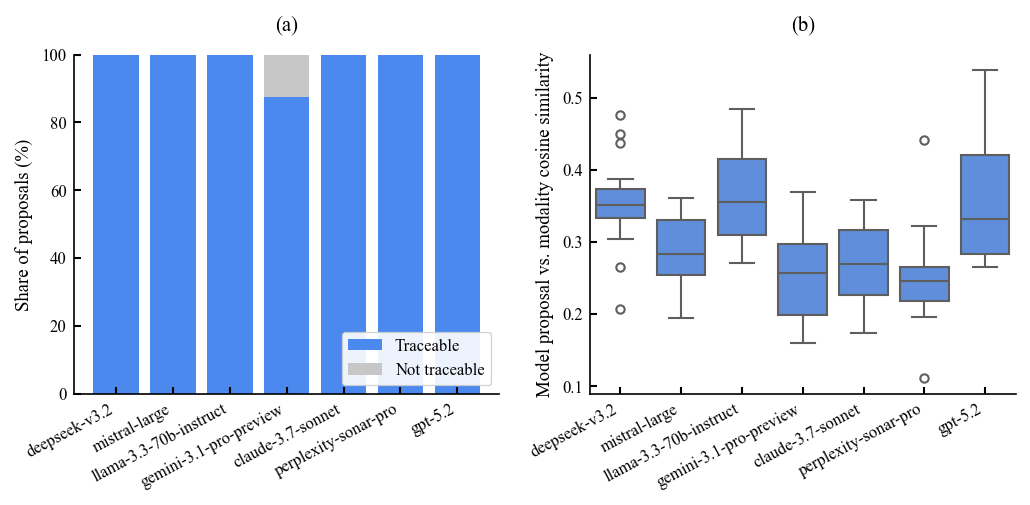

In [60]:
# Extra visualizations for Test 1 with publication-ready exports.
if "test1_results" not in globals() or not isinstance(test1_results, pd.DataFrame):
    test1_results = pd.read_csv(path_test1_results)

viz_df = test1_results.copy()
viz_df.columns = [str(column).strip() for column in viz_df.columns]

# Ensure expected analysis columns are present or safely derived.
if "is_traceable" not in viz_df.columns:
    viz_df["is_traceable"] = pd.to_numeric(viz_df.get("lit_matches", 0), errors="coerce").fillna(0).gt(0)
else:
    viz_df["is_traceable"] = viz_df["is_traceable"].fillna(False).astype(bool)

if "is_novel" not in viz_df.columns:
    if "ontologically_novel" in viz_df.columns:
        viz_df["is_novel"] = viz_df["ontologically_novel"]
    else:
        viz_df["is_novel"] = np.where(viz_df["is_traceable"], "NO", "MAYBE")

for column in ["max_similarity", "avg_similarity", "lit_matches", "lit_best_score"]:
    if column in viz_df.columns:
        viz_df[column] = pd.to_numeric(viz_df[column], errors="coerce")

if "inside_convex_hull" in viz_df.columns:
    viz_df["inside_convex_hull"] = viz_df["inside_convex_hull"].fillna(False).astype(bool)
else:
    viz_df["inside_convex_hull"] = False

viz_df["model"] = viz_df["model"].astype(str)
model_order = viz_df["model"].value_counts().index.tolist()

sim_train_label = "Model proposal vs. modality cosine similarity"
sim_lit_label = "Model proposal vs. literature cosine similarity"

# Match the blue-gray palette logic used across previous figures.
primary_blue = WHITE_SKY_CMAP(0.70)
secondary_blue = WHITE_SKY_CMAP(0.45)
dark_gray = "gray"
neutral_gray = BLUE_GRAY_RAMP[4]

out_dir = Path("results/test1")
fig_dir = out_dir / "extra_visualizations"
fig_dir.mkdir(parents=True, exist_ok=True)
saved_files = []

# -------- Row 1 figure: traceability composition + similarity distribution --------
fig_row1, axes_row1 = plt.subplots(1, 2, figsize=(7, 3.5))

trace_counts = (
    viz_df.groupby(["model", "is_traceable"]).size().unstack(fill_value=0).reindex(model_order).fillna(0)
)
trace_counts.columns = [bool(column) for column in trace_counts.columns]
true_counts = trace_counts[True] if True in trace_counts.columns else pd.Series(0, index=model_order)
false_counts = trace_counts[False] if False in trace_counts.columns else pd.Series(0, index=model_order)
total_counts = (true_counts + false_counts).replace(0, np.nan)
true_pct = (true_counts / total_counts).fillna(0) * 100.0
false_pct = (false_counts / total_counts).fillna(0) * 100.0

axes_row1[0].bar(model_order, true_pct.values, color=primary_blue, label="Traceable")
axes_row1[0].bar(model_order, false_pct.values, bottom=true_pct.values, color=neutral_gray, label="Not traceable")
axes_row1[0].set_title("(a)")
axes_row1[0].set_xlabel("")
axes_row1[0].set_ylabel("Share of proposals (%)")
axes_row1[0].set_ylim(0, 100)
axes_row1[0].tick_params(axis="x", rotation=28)
for label in axes_row1[0].get_xticklabels():
    label.set_ha("right")
axes_row1[0].legend(loc="lower right", framealpha=0.9)

sns.boxplot(
    data=viz_df,
    x="model",
    y="max_similarity",
    order=model_order,
    ax=axes_row1[1],
    color=primary_blue,
)

axes_row1[1].set_title("(b)")
axes_row1[1].set_xlabel("")
axes_row1[1].set_ylabel(sim_train_label)
axes_row1[1].tick_params(axis="x", rotation=28)
for label in axes_row1[1].get_xticklabels():
    label.set_ha("right")

fig_row1.tight_layout()
row1_path = out_dir / "extra_visualizations_row1.png"
fig_row1.savefig(row1_path, bbox_inches="tight")
print(f"Saved diagnostics row 1: {row1_path}")
saved_files.append(row1_path)
plt.show()

Saved diagnostics row 2: results/test1/extra_visualizations_row2.png


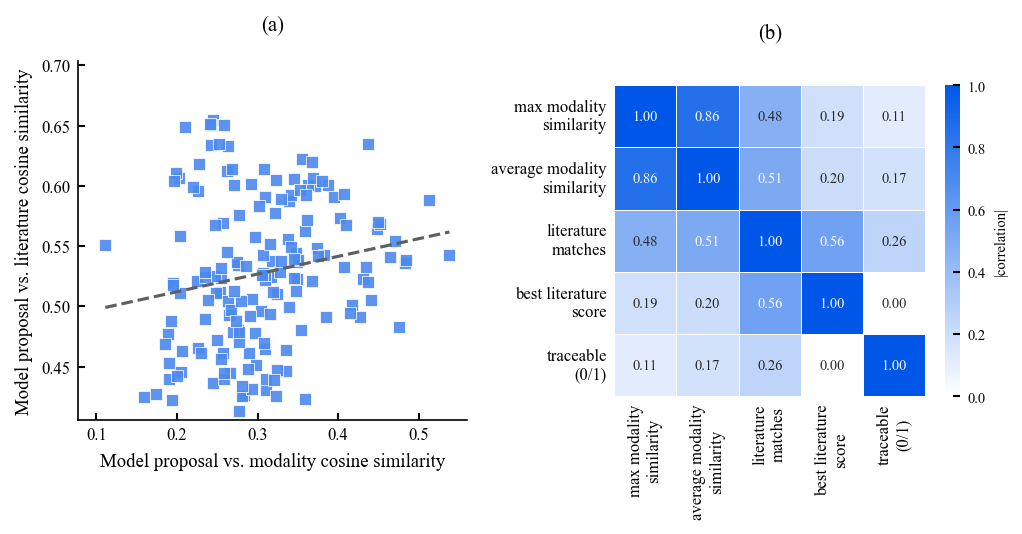

Saved correlation matrix: results/test1/extra_visualizations_corr.csv
Total extra visualizations saved: 12


In [82]:
# -------- Row 2 figure: cross-similarity scatter + correlation heatmap --------
fig_row2, axes_row2 = plt.subplots(1, 2, figsize=(7, 3.5))
TITLE_Y = 1.02

corr = None
if "lit_best_score" in viz_df.columns and "max_similarity" in viz_df.columns:
    trace_palette = {False: neutral_gray, True: primary_blue}
    hull_markers = {False: "o", True: "s"}

    plot_scatter_df = viz_df.dropna(subset=["max_similarity", "lit_best_score"]).copy()
    available_trace = sorted(plot_scatter_df["is_traceable"].dropna().unique().tolist())

    if len(plot_scatter_df) == 0:
        axes_row2[0].text(0.5, 0.5, "No rows have both max_similarity and lit_best_score.", ha="center", va="center")
    elif len(available_trace) == 1:
        only_trace = bool(available_trace[0])
        for hull_state in [False, True]:
            group = plot_scatter_df[plot_scatter_df["inside_convex_hull"] == hull_state]
            if len(group) == 0:
                continue
            axes_row2[0].scatter(
                group["max_similarity"],
                group["lit_best_score"],
                c=[trace_palette[only_trace]],
                marker=hull_markers[hull_state],
                label=f"inside_hull={hull_state}",
                s=30,
                alpha=0.9,
                edgecolors="white",
                linewidths=0.4,
            )
        if len(plot_scatter_df) >= 2:
            sns.regplot(
                data=plot_scatter_df,
                x="max_similarity",
                y="lit_best_score",
                scatter=False,
                ci=None,
                line_kws={"color": THRESHOLD_COLOR, "linestyle": "--"},
                ax=axes_row2[0],
            )
        miss_false = int(((viz_df["is_traceable"] == False) & viz_df["lit_best_score"].isna()).sum())
        miss_true = int(((viz_df["is_traceable"] == True) & viz_df["lit_best_score"].isna()).sum())
        x_min = float(plot_scatter_df["max_similarity"].min())
        x_max = float(plot_scatter_df["max_similarity"].max())
        y_min = float(plot_scatter_df["lit_best_score"].min())
        y_max = float(plot_scatter_df["lit_best_score"].max())
        x_span = max(1e-6, x_max - x_min)
        y_span = max(1e-6, y_max - y_min)
        axes_row2[0].set_xlim(x_min - 0.08 * x_span, x_max + 0.05 * x_span)
        axes_row2[0].set_ylim(y_min - 0.03 * y_span, y_max + 0.20 * y_span)
    else:
        for trace_state in [False, True]:
            for hull_state in [False, True]:
                group = plot_scatter_df[
                    (plot_scatter_df["is_traceable"] == trace_state)
                    & (plot_scatter_df["inside_convex_hull"] == hull_state)
                ]
                if len(group) == 0:
                    continue
                axes_row2[0].scatter(
                    group["max_similarity"],
                    group["lit_best_score"],
                    c=[trace_palette[trace_state]],
                    marker=hull_markers[hull_state],
                    label=f"traceable={trace_state}, inside_hull={hull_state}",
                    s=30,
                    alpha=0.9,
                    edgecolors="white",
                    linewidths=0.4,
                )

    axes_row2[0].set_title("(a)", y=TITLE_Y)
    axes_row2[0].set_xlabel(sim_train_label)
    axes_row2[0].set_ylabel(sim_lit_label)
    handles, labels = axes_row2[0].get_legend_handles_labels()
    if len(handles) > 1:
        axes_row2[0].legend(loc="best")
else:
    axes_row2[0].text(0.5, 0.5, "Required columns not available", ha="center", va="center")
    axes_row2[0].set_title("(a)", y=TITLE_Y)

numeric_cols = [
    column for column in ["max_similarity", "avg_similarity", "lit_matches", "lit_best_score"]
    if column in viz_df.columns
]
corr_df = viz_df[numeric_cols].copy() if numeric_cols else pd.DataFrame()
corr_df["is_traceable_num"] = viz_df["is_traceable"].astype(int)
corr_df["inside_hull_num"] = viz_df["inside_convex_hull"].astype(int)

colorbar = None
variable_cols = [column for column in corr_df.columns if corr_df[column].nunique(dropna=True) > 1]
if len(variable_cols) >= 2:
    corr = corr_df[variable_cols].corr(numeric_only=True)
    corr = corr.replace([np.inf, -np.inf], np.nan).fillna(0.0).abs()
    heatmap = sns.heatmap(
        corr,
        ax=axes_row2[1],
        cmap=WHITE_SKY_CMAP,
        vmin=0.0,
        vmax=1.0,
        linewidths=0.4,
        linecolor="white",
        square=True,
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 7},
    )
    axes_row2[1].set_title("(b)", y=TITLE_Y)
    corr_label_map = {
        "max_similarity": "max modality\nsimilarity",
        "avg_similarity": "average modality\nsimilarity",
        "lit_matches": "literature\nmatches",
        "lit_best_score": "best literature\nscore",
        "is_traceable_num": "traceable\n(0/1)",
        "inside_hull_num": "inside convex hull\n(0/1)",
    }
    axes_row2[1].set_xticklabels(
        [corr_label_map.get(t.get_text(), t.get_text()) for t in axes_row2[1].get_xticklabels()],
        rotation=90,
    )
    axes_row2[1].set_yticklabels(
        [corr_label_map.get(t.get_text(), t.get_text()) for t in axes_row2[1].get_yticklabels()]
    )
    axes_row2[1].tick_params(axis="both", length=0)
    if heatmap.collections:
        colorbar = heatmap.collections[0].colorbar
        if colorbar is not None:
            colorbar.set_label("|correlation|", fontsize=7)
            colorbar.ax.tick_params(labelsize=7)
else:
    axes_row2[1].text(0.5, 0.5, "Not enough non-constant numeric columns", ha="center", va="center")
    axes_row2[1].set_title("(b)", y=TITLE_Y)

fig_row2.tight_layout()

# Force the colorbar to have exactly the same vertical span as the heatmap axes.
if colorbar is not None:
    heat_pos = axes_row2[1].get_position()
    cbar_pos = colorbar.ax.get_position()
    colorbar.ax.set_position([cbar_pos.x0, heat_pos.y0, cbar_pos.width, heat_pos.height])

# Re-apply panel tags at one shared vertical coordinate.
axes_row2[0].set_title("(a)", y=TITLE_Y)
axes_row2[1].set_title("(b)", y=TITLE_Y, pad=20)

row2_path = out_dir / "extra_visualizations_row2.png"
fig_row2.savefig(row2_path, bbox_inches="tight")
print(f"Saved diagnostics row 2: {row2_path}")
saved_files.append(row2_path)
plt.show()

corr_csv_path = out_dir / "extra_visualizations_corr.csv"
if corr is not None:
    corr.to_csv(corr_csv_path)
    print(f"Saved correlation matrix: {corr_csv_path}")
print(f"Total extra visualizations saved: {len(saved_files)}")


**Figure caption (row 1).** **(a)** Traceability composition by model, showing traceable vs. non-traceable proposal proportions. **(b)** Modality similarity profile by model across all reference modalities.

**Figure caption (row 2).** **(a)** Scatter of modality-similarity vs. literature-similarity scores per proposal. When only one traceability group has valid literature-similarity scores, that group is plotted alone and missing-score counts are reported in the caption: proposals with is\_traceable=False and missing lit\_best\_score are counted separately from those with is\_traceable=True. **(b)** Absolute correlation heatmap between evaluation metrics.

### 6.5 Hierarchical View of Agglomerative Clusters

Visualize the same agglomerative structure as a dendrogram and a 2D scatter projection for interpretable cluster inspection.

Saved hierarchical clustering dendrogram:  results/test1/hierarc_clustering_dendrogram.png


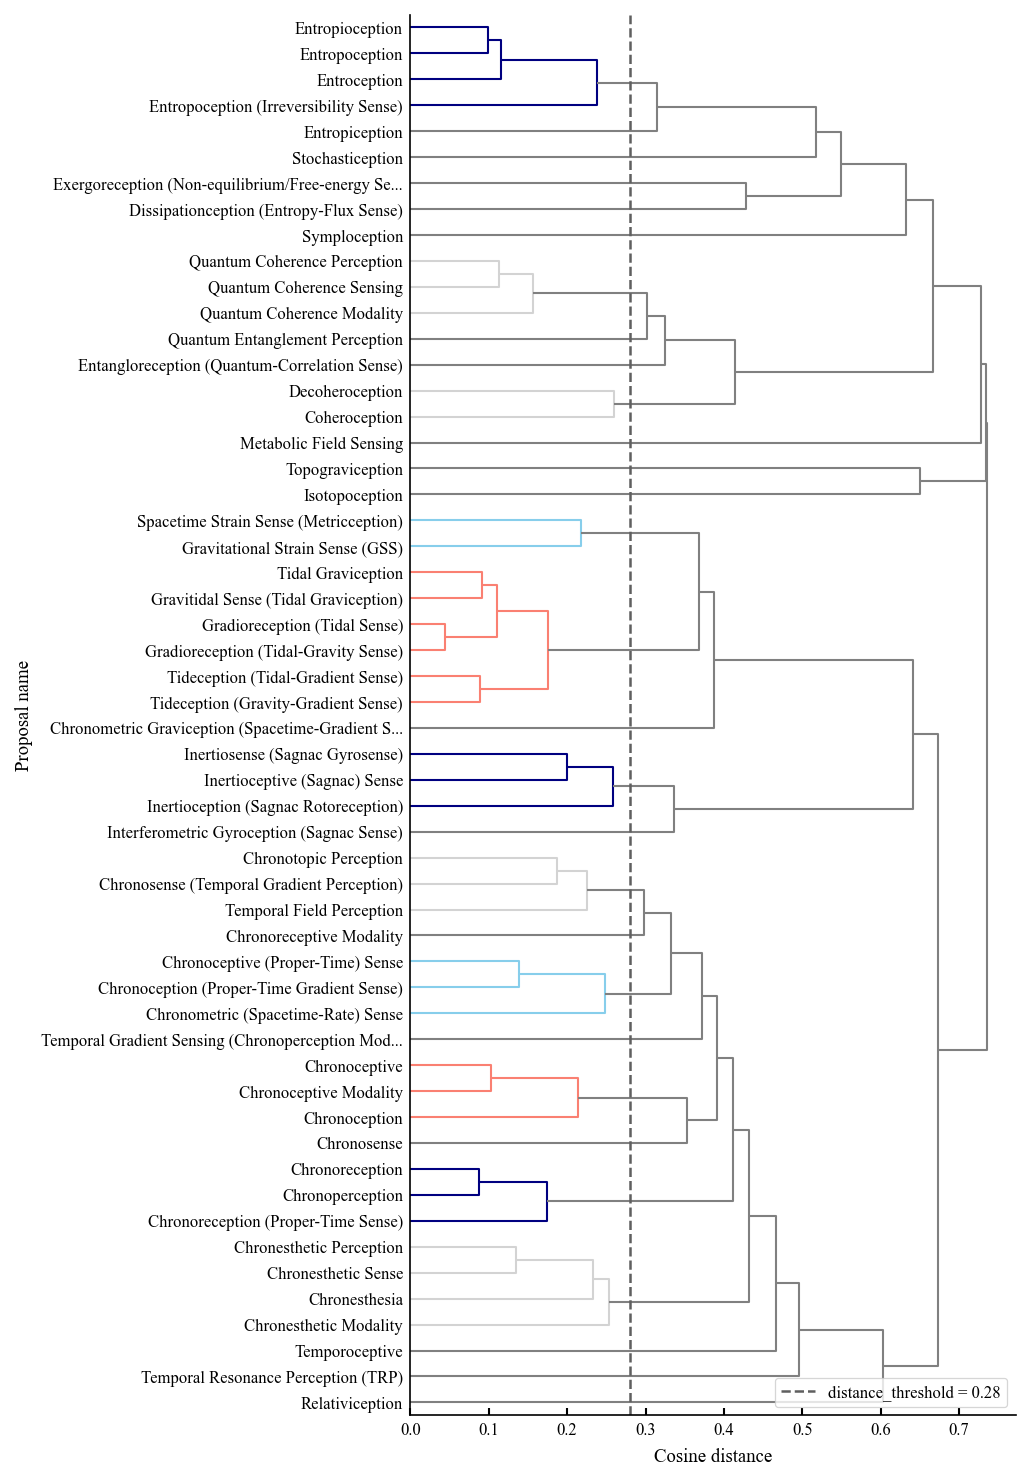

In [62]:
if "dist_uu" not in globals() or "unique_work_df" not in globals():
    raise RuntimeError("Run the previous clustering cell first to compute dist_uu and unique_work_df.")

# Convert full distance matrix into condensed form expected by scipy linkage.
condensed_dist = squareform(dist_uu, checks=False)
Z = linkage(condensed_dist, method="average")

# Shorten overly long labels for readability in dense dendrograms.
def _short_label(text: str, max_len: int = 48) -> str:
    t = str(text).strip()
    return t if len(t) <= max_len else (t[: max_len - 1] + "...")

leaf_labels = [_short_label(x) for x in unique_work_df["proposal_name"].tolist()]

fig, ax = plt.subplots(figsize=(7, 10))
dendrogram(
    Z,
    labels=leaf_labels,
    orientation="right",
    leaf_font_size=8,
    color_threshold=distance_threshold,
    above_threshold_color="gray",
    ax=ax,
 )

# Mark the exact cut level used for AgglomerativeClustering distance_threshold.
ax.axvline(
    distance_threshold,
    color=THRESHOLD_COLOR,
    linestyle="--",
    linewidth=1.2,
    label=f"distance_threshold = {distance_threshold:.2f}",
)
ax.set_xlabel("Cosine distance")
ax.set_ylabel("Proposal name")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.0)
plt.tight_layout()
fig.savefig(out_dir / "hierarc_clustering_dendrogram.png")
print("Saved hierarchical clustering dendrogram: ", out_dir / "hierarc_clustering_dendrogram.png")
plt.show()

**Figure caption.** Hierarchical clustering dendrogram (average-linkage Ward distance) over unique proposals. Leaf labels are proposal names; horizontal cut indicates the distance threshold used to define raw clusters.

#### 6.5.1 Agglomerative Cluster Scatter (PCA Projection)

Show cluster assignments in 2D with centroid labels to complement the dendrogram view.

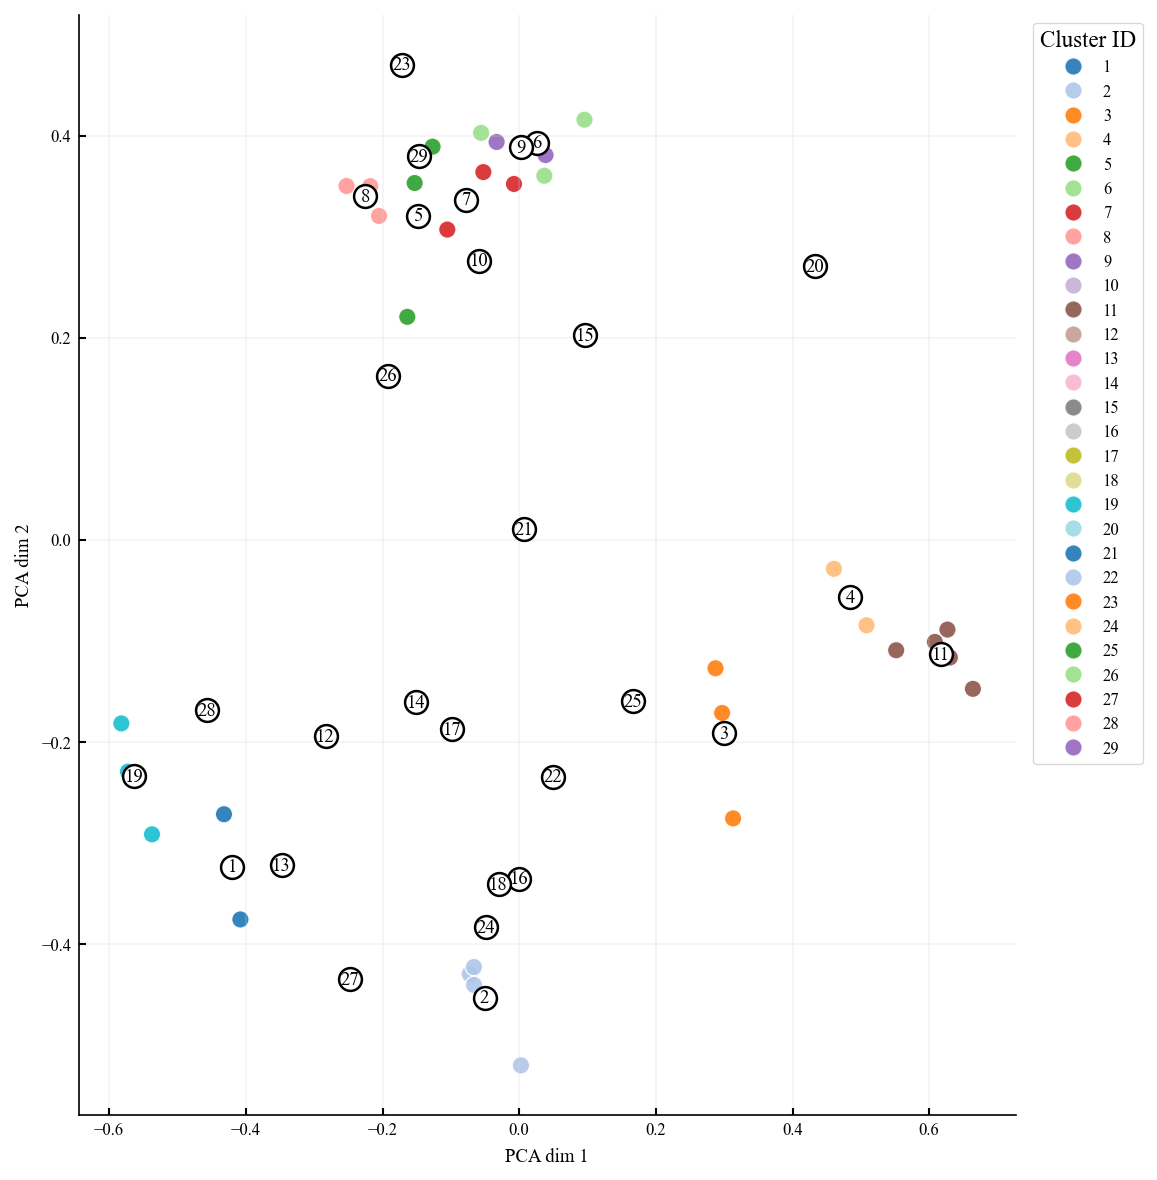

In [63]:
if "combined_embeddings" not in globals() or "unique_work_df" not in globals():
    raise RuntimeError("Run the embedding/clustering cell first to compute combined_embeddings and unique_work_df.")

proj_2d = PCA(n_components=2, random_state=42).fit_transform(combined_embeddings)
plot_df = unique_work_df.copy()
plot_df["pca_x"] = proj_2d[:, 0]
plot_df["pca_y"] = proj_2d[:, 1]

fig, ax = plt.subplots(figsize=(7, 8))
sns.scatterplot(
    data=plot_df,
    x="pca_x",
    y="pca_y",
    hue="raw_cluster_id",
    palette="tab20",
    s=70,
    alpha=0.9,
    ax=ax,
    legend="full",
)

# Mark cluster centroids and annotate cluster IDs for quick reading.
centroids = plot_df.groupby("raw_cluster_id")[["pca_x", "pca_y"]].mean().reset_index()
ax.scatter(
    centroids["pca_x"],
    centroids["pca_y"],
    s=120,
    c="white",
    edgecolors="black",
    linewidths=1.2,
    marker="o",
    zorder=3,
)
for _, c in centroids.iterrows():
    ax.text(
        c["pca_x"],
        c["pca_y"],
        str(int(c["raw_cluster_id"])),
        ha="center",
        va="center",
        fontsize=9,
        zorder=4,
)

ax.set_xlabel("PCA dim 1")
ax.set_ylabel("PCA dim 2")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Cluster ID")
plt.show()

**Figure caption.** Agglomerative cluster assignments projected onto the first two PCA components. Each point is a unique proposal; color encodes raw cluster ID; centroid markers are shown in the cluster color.

### 6.6 t-SNE Projection for Local Similarity Audit

Use t-SNE to inspect local neighborhood structure among unique proposals.

#### 6.6.1 Compute t-SNE Coordinates

Project fused proposal embeddings to 2D space for label-aware visualization.

In [64]:
perplexity = max(5, min(20, (len(unique_work_df) - 1) // 3))
tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto", perplexity=perplexity)
tsne_2d = tsne.fit_transform(combined_embeddings)
unique_work_df["tsne_x"] = tsne_2d[:, 0]
unique_work_df["tsne_y"] = tsne_2d[:, 1]

#### 6.6.2 Labeled t-SNE Visualization

Render proposal-name labels with overlap handling and connector lines for dense regions.

Saved t-SNE with labels: results/test1/tsne_with_labels.png


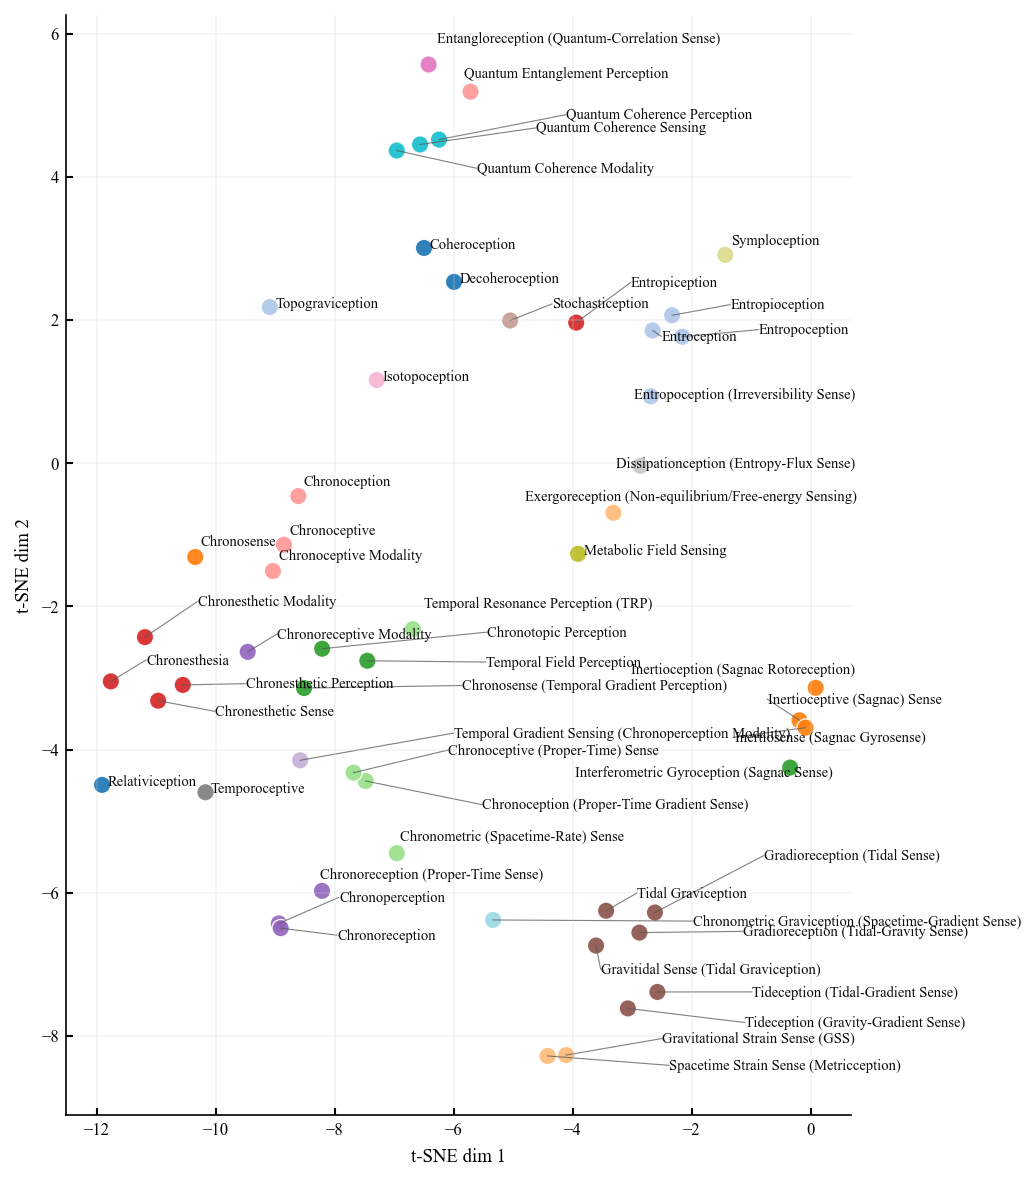

Step 2 complete
Raw clusters detected: 29
Distance threshold: 0.28
Embedding weights -> name: 0.65, description: 0.35
Label collision handling: adjustText + overlap-only bbox-left connectors
Labels with connectors: 32 / 54


,unique_names,total_occurrences
raw_cluster_id,,
8,3,34
19,3,33
26,1,23
9,3,17
2,4,9
11,6,7
27,1,6
7,4,5
1,2,5


In [ ]:
fig, ax = plt.subplots(figsize=(7, 8))
sns.scatterplot(
    data=unique_work_df,
    x="tsne_x",
    y="tsne_y",
    hue="raw_cluster_id",
    palette="tab20",
    s=70,
    alpha=0.92,
    legend=False,
    ax=ax,
)

x_span = max(1e-8, float(unique_work_df["tsne_x"].max() - unique_work_df["tsne_x"].min()))
y_span = max(1e-8, float(unique_work_df["tsne_y"].max() - unique_work_df["tsne_y"].min()))
dx = 0.006 * x_span
dy = 0.006 * y_span

texts = []
for _, row in unique_work_df.iterrows():
    txt = ax.text(
        row["tsne_x"] + dx,
        row["tsne_y"] + dy,
        str(row["proposal_name"]),
        fontsize=7,
        alpha=0.96,
        ha="left",
        va="center",
    )
    texts.append(txt)

# Detect which labels overlap in the initial placement.
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
initial_bboxes = [t.get_window_extent(renderer=renderer) for t in texts]
needs_connector = [False] * len(texts)
for i in range(len(initial_bboxes)):
    for j in range(i + 1, len(initial_bboxes)):
        if initial_bboxes[i].overlaps(initial_bboxes[j]):
            needs_connector[i] = True
            needs_connector[j] = True

# Prefer automatic collision resolution if adjustText is installed (without built-in arrows).
used_adjust_text = False
try:
    from adjustText import adjust_text

    adjust_text(
        texts,
        x=unique_work_df["tsne_x"].to_numpy(),
        y=unique_work_df["tsne_y"].to_numpy(),
        ax=ax,
        expand_text=(1.08, 1.22),
        expand_points=(1.05, 1.12),
        force_text=(0.35, 0.55),
        force_points=(0.15, 0.35),
        lim=300,
    )
    used_adjust_text = True
except Exception:
    pass

# Draw connectors only for labels that had overlap pressure initially.
# Endpoint is the final rendered left edge of label bbox (pixel-precise).
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
inv = ax.transData.inverted()
for k, (txt, (_, row)) in enumerate(zip(texts, unique_work_df.iterrows())):
    if not needs_connector[k]:
        continue
    txt.set_ha("left")
    txt.set_va("center")
    bbox = txt.get_window_extent(renderer=renderer)
    x_left_px = bbox.x0 - 0.5
    y_mid_px = 0.5 * (bbox.y0 + bbox.y1)
    x1, y1 = inv.transform((x_left_px, y_mid_px))
    x0, y0 = float(row["tsne_x"]), float(row["tsne_y"])
    ax.plot([x0, x1], [y0, y1], color="0.35", lw=0.55, alpha=0.75, zorder=1)

ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(out_dir / "tsne_with_labels.png")
plt.show()

raw_cluster_sizes = (
    unique_work_df.groupby("raw_cluster_id")
    .agg(
        unique_names=("proposal_name", "count"),
        total_occurrences=("n_occurrences", "sum"),
    )
    .sort_values(["total_occurrences", "unique_names"], ascending=[False, False])
)

display(raw_cluster_sizes.head(30))

**Figure caption.** t-SNE projection of unique proposal embeddings (name + description). Points are colored by raw cluster ID (tab20 palette). Proposal names are placed with overlap-aware connectors; labels that required repositioning are linked to their data point by a thin grey line.

Visualize `raw_cluster_sizes` using rank-ordered bars, a cumulative coverage curve, and size/composition scatter to inspect concentration and balance across clusters.

Saved raw cluster size diagnostics: results/test1/raw_cluster_size_diagnostics.png


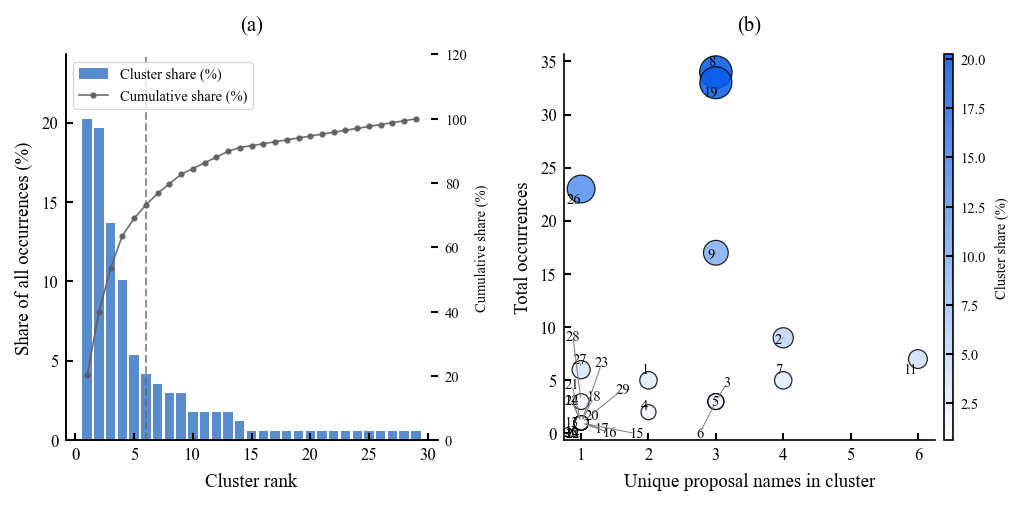

In [85]:
# Visual diagnostics for raw_cluster_sizes.
# If the table is not in memory (e.g., after kernel restart), rebuild it from unique_work_df.
if "raw_cluster_sizes" not in globals() or not isinstance(raw_cluster_sizes, pd.DataFrame):
    if "unique_work_df" not in globals():
        raise RuntimeError("Run the Step 2 t-SNE visualization cell first to compute raw_cluster_sizes.")
    raw_cluster_sizes = (
        unique_work_df.groupby("raw_cluster_id")
        .agg(
            unique_names=("proposal_name", "count"),
            total_occurrences=("n_occurrences", "sum"),
        )
        .sort_values(["total_occurrences", "unique_names"], ascending=[False, False])
    )

rcs = raw_cluster_sizes.reset_index().copy()
rcs = rcs.sort_values(["total_occurrences", "unique_names"], ascending=[False, False]).reset_index(drop=True)
rcs["cluster_rank"] = np.arange(1, len(rcs) + 1)
total_all = max(1, int(rcs["total_occurrences"].sum()))
rcs["share_pct"] = 100.0 * rcs["total_occurrences"] / total_all
rcs["cum_share_pct"] = rcs["share_pct"].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={"width_ratios": [1, 1.2]})

# (a) Pareto-style concentration curve.
axes[0].bar(
    rcs["cluster_rank"],
    rcs["share_pct"],
    color=BLUE_GRAY_RAMP[1],
    alpha=0.8,
    label="Cluster share (%)",
)
ax2 = axes[0].twinx()
ax2.plot(
    rcs["cluster_rank"],
    rcs["cum_share_pct"],
    color=THRESHOLD_COLOR,
    marker="o",
    lw=0.8,
    markersize=2,
    alpha=0.9,
    label="Cumulative share (%)",
)
axes[0].set_title("(a)")
axes[0].set_xlabel("Cluster rank")
axes[0].set_ylabel("Share of all occurrences (%)")
ax2.set_ylabel("Cumulative share (%)", fontsize=7)
ax2.tick_params(axis="y", labelsize=7)
axes[0].set_ylim(0, max(5, rcs["share_pct"].max() * 1.2))
ax2.set_ylim(0, 120)
axes[0].axvline(max(1, int(np.ceil(0.2 * len(rcs)))), ls="--", lw=1, color="0.4", alpha=0.7)
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=7)

# (b) Size vs composition scatter (occurrences vs unique proposal names).
sc = axes[1].scatter(
    rcs["unique_names"],
    rcs["total_occurrences"],
    s=40 + 10 * rcs["share_pct"],
    c=rcs["share_pct"],
    cmap=WHITE_SKY_CMAP,
    alpha=0.85,
    edgecolors="black",
)
_texts_c = [
    axes[1].text(
        row["unique_names"],
        row["total_occurrences"],
        str(int(row["raw_cluster_id"])),
        fontsize=7,
        ha="center",
        va="center",
    )
    for _, row in rcs.iterrows()
]
try:
    import io
    from contextlib import redirect_stderr, redirect_stdout
    from adjustText import adjust_text as _adj

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        _adj(
            _texts_c,
            x=rcs["unique_names"].tolist(),
            y=rcs["total_occurrences"].tolist(),
            ax=axes[1],
            arrowprops=dict(arrowstyle="-", color="0.5", lw=0.5),
            expand=(1.3, 1.5),
            force_points=(0.4, 0.6),
            force_text=(0.4, 0.6),
        )
except ImportError:
    pass
axes[1].set_title("(b)")
axes[1].set_xlabel("Unique proposal names in cluster")
axes[1].set_ylabel("Total occurrences")

cbar = plt.colorbar(sc, ax=axes[1], aspect=40, pad=0.02)
cbar.set_label("Cluster share (%)", fontsize=7)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
fig.savefig(out_dir / "raw_cluster_size_diagnostics.png")
print(f"Saved raw cluster size diagnostics: {out_dir / 'raw_cluster_size_diagnostics.png'}")
plt.show()

**Figure caption.** **(a)** Pareto concentration view of cluster mass. **(b)** Cluster composition comparing unique proposal names and total occurrence counts.

#### 6.6.3 Canonical Label Construction

Create canonical cluster labels directly from raw similarity clusters using representative (medoid-like) proposals.

In [93]:
# Clear stale columns for idempotent re-runs.
stale_cols = ["final_cluster_key", "canonical_label", "cluster_representative", "cluster_avg_similarity"]
unique_work_df = unique_work_df.drop(columns=[c for c in stale_cols if c in unique_work_df.columns], errors="ignore")

# Keep one canonical cluster per raw similarity cluster.
unique_work_df["final_cluster_key"] = "cluster_" + unique_work_df["raw_cluster_id"].astype(str)

cluster_label_rows = []
for cid, g in unique_work_df.groupby("raw_cluster_id", sort=True):
    idx = g.index.to_numpy()
    sim_block = sim_uu[np.ix_(idx, idx)]

    # Representative (medoid-like): point with highest mean similarity inside its cluster.
    mean_sim = sim_block.mean(axis=1)
    rep_local = int(np.argmax(mean_sim))
    rep_idx = idx[rep_local]
    rep_name = str(unique_work_df.loc[rep_idx, "proposal_name"]).strip()

    canonical_label = rep_name
    cluster_label_rows.append(
        {
            "raw_cluster_id": int(cid),
            "canonical_label": canonical_label,
            "cluster_representative": rep_name,
            "cluster_avg_similarity": float(np.mean(sim_block)),
        }
    )

cluster_label_df = pd.DataFrame(cluster_label_rows)
unique_work_df = unique_work_df.merge(cluster_label_df, on="raw_cluster_id", how="left")

canonical_summary = (
    unique_work_df.groupby(["raw_cluster_id", "canonical_label", "cluster_representative"], as_index=False)
    .agg(
        unique_names=("proposal_name", "count"),
        total_occurrences=("n_occurrences", "sum"),
        cluster_avg_similarity=("cluster_avg_similarity", "first"),
        examples=("proposal_name", lambda s: "; ".join(sorted(s.tolist())[:5])),
    )
    .sort_values(["total_occurrences", "unique_names", "raw_cluster_id"], ascending=[False, False, True])
)

print("Step 3 complete")
print("Canonical labels are now data-driven and 1:1 with similarity clusters.")
print(f"Final canonical clusters: {unique_work_df['canonical_label'].nunique()}")
display(canonical_summary.head(40))

# Optional audit: inspect cluster assignments alphabetically by proposal name.
audit_view = unique_work_df[[
    "proposal_name", "raw_cluster_id", "canonical_label", "cluster_representative",
    "n_occurrences", "n_models"
]].sort_values(["raw_cluster_id", "proposal_name"]).reset_index(drop=True)
display(audit_view.head(80))

Step 3 complete
Canonical labels are now data-driven and 1:1 with similarity clusters.
Final canonical clusters: 29


,raw_cluster_id,canonical_label,cluster_representative,unique_names,total_occurrences,cluster_avg_similarity,examples
7,8,Chronoceptive,Chronoceptive,3,34,0.882269,Chronoception; Chronoceptive; Chronoceptive Mo...
18,19,Quantum Coherence Perception,Quantum Coherence Perception,3,33,0.905357,Quantum Coherence Modality; Quantum Coherence ...
25,26,Temporal Resonance Perception (TRP),Temporal Resonance Perception (TRP),1,23,1.000000,Temporal Resonance Perception (TRP)
8,9,Chronoperception,Chronoperception,3,17,0.903328,Chronoperception; Chronoreception; Chronorecep...
1,2,Entropioception,Entropioception,4,9,0.869652,Entroception; Entropioception; Entropoception;...
10,11,Gradioreception (Tidal-Gravity Sense),Gradioreception (Tidal-Gravity Sense),6,7,0.885278,Gradioreception (Tidal Sense); Gradioreception...
26,27,Entropiception,Entropiception,1,6,1.000000,Entropiception
6,7,Chronesthetic Sense,Chronesthetic Sense,4,5,0.829689,Chronesthesia; Chronesthetic Modality; Chrones...
0,1,Coheroception,Coheroception,2,5,0.870071,Coheroception; Decoheroception
2,3,Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,3,3,0.840530,Inertioception (Sagnac Rotoreception); Inertio...


,proposal_name,raw_cluster_id,canonical_label,cluster_representative,n_occurrences,n_models
0,Coheroception,1,Coheroception,Coheroception,3,1
1,Decoheroception,1,Coheroception,Coheroception,2,1
2,Entroception,2,Entropioception,Entropioception,2,1
3,Entropioception,2,Entropioception,Entropioception,1,1
4,Entropoception,2,Entropioception,Entropioception,5,1
5,Entropoception (Irreversibility Sense),2,Entropioception,Entropioception,1,1
6,Inertioception (Sagnac Rotoreception),3,Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,1,1
7,Inertioceptive (Sagnac) Sense,3,Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,1,1
8,Inertiosense (Sagnac Gyrosense),3,Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,1,1
9,Gravitational Strain Sense (GSS),4,Spacetime Strain Sense (Metricception),Spacetime Strain Sense (Metricception),1,1


#### 6.6.4 Nearest-Neighbor Audit Table

For each unique proposal, list top-3 nearest neighbors and whether they remain in the same cluster.

In [101]:
# Step 3b. Audit table: top-3 nearest neighbors per unique proposal (cosine similarity).
if "sim_uu" not in globals() or "unique_work_df" not in globals():
    raise RuntimeError("Run Step 2 and Step 3 first: 'sim_uu' and 'unique_work_df' are required.")

n_neighbors = 3
names = unique_work_df["proposal_name"].astype(str).tolist()
cluster_ids = unique_work_df["raw_cluster_id"].tolist()

rows = []
for i, name in enumerate(names):
    sims = sim_uu[i].copy()
    sims[i] = -1.0  # Exclude self-match.
    nn_idx = np.argsort(sims)[-n_neighbors:][::-1]

    row = {
        "proposal_name": name,
        "raw_cluster_id": int(cluster_ids[i]),
        "canonical_label": unique_work_df.iloc[i]["canonical_label"],
    }

    for rank, j in enumerate(nn_idx, start=1):
        row[f"nn{rank}_name"] = names[j]
        row[f"nn{rank}_similarity"] = float(sims[j])
        row[f"nn{rank}_same_cluster"] = bool(cluster_ids[i] == cluster_ids[j])

    rows.append(row)

top3_neighbors_df = pd.DataFrame(rows)

# Human-readable sorting: weakest local support first (lowest top-1 similarity).
top3_neighbors_df = top3_neighbors_df.sort_values(
    ["raw_cluster_id", "nn1_similarity", "proposal_name"],
    ascending=[True, True, True]
).reset_index(drop=True)

display(top3_neighbors_df.head(120))

# Save for appendix and manual labeling audit.
audit_dir = Path("results/test1/proposal_compression")
audit_dir.mkdir(parents=True, exist_ok=True)
audit_path = audit_dir / "03b_top3_nearest_neighbors.csv"
top3_neighbors_df.to_csv(audit_path, index=False)
print(f"Saved nearest-neighbor audit table: {audit_path}")

# Optional quick diagnostics.
same_cluster_rate = top3_neighbors_df[["nn1_same_cluster", "nn2_same_cluster", "nn3_same_cluster"]].mean()
print("Top-k same-cluster rate:")
print((same_cluster_rate * 100).round(1).astype(str) + "%")

,proposal_name,raw_cluster_id,canonical_label,nn1_name,nn1_similarity,nn1_same_cluster,nn2_name,nn2_similarity,nn2_same_cluster,nn3_name,nn3_similarity,nn3_same_cluster
0,Coheroception,1,Coheroception,Decoheroception,0.740141,True,Quantum Coherence Sensing,0.685682,False,Quantum Coherence Perception,0.674249,False
1,Decoheroception,1,Coheroception,Coheroception,0.740141,True,Entropiception,0.658058,False,Quantum Coherence Perception,0.638697,False
2,Entropoception (Irreversibility Sense),2,Entropioception,Entroception,0.771894,True,Entropioception,0.763569,True,Entropoception,0.751970,True
3,Entroception,2,Entropioception,Entropioception,0.890445,True,Entropoception,0.878882,True,Entropoception (Irreversibility Sense),0.771894,True
4,Entropioception,2,Entropioception,Entropoception,0.900456,True,Entroception,0.890445,True,Entropoception (Irreversibility Sense),0.763569,True
5,Entropoception,2,Entropioception,Entropioception,0.900456,True,Entroception,0.878882,True,Entropoception (Irreversibility Sense),0.751970,True
6,Inertioception (Sagnac Rotoreception),3,Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,0.759332,True,Inertiosense (Sagnac Gyrosense),0.723040,True,Interferometric Gyroception (Sagnac Sense),0.588657,False
7,Inertioceptive (Sagnac) Sense,3,Inertioceptive (Sagnac) Sense,Inertiosense (Sagnac Gyrosense),0.800011,True,Inertioception (Sagnac Rotoreception),0.759332,True,Interferometric Gyroception (Sagnac Sense),0.703844,False
8,Inertiosense (Sagnac Gyrosense),3,Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,0.800011,True,Inertioception (Sagnac Rotoreception),0.723040,True,Interferometric Gyroception (Sagnac Sense),0.700282,False
9,Gravitational Strain Sense (GSS),4,Spacetime Strain Sense (Metricception),Spacetime Strain Sense (Metricception),0.782812,True,Tideception (Gravity-Gradient Sense),0.703376,False,Gravitidal Sense (Tidal Graviception),0.691233,False


Saved nearest-neighbor audit table: results/test1/proposal_compression/03b_top3_nearest_neighbors.csv
Top-k same-cluster rate:
nn1_same_cluster    66.7%
nn2_same_cluster    53.7%
nn3_same_cluster    25.9%
dtype: object


#### 6.6.5 Boundary-Case Flagging

Flag potentially ambiguous assignments using low top-1 similarity and weak same-cluster agreement among top neighbors.

In [102]:
# Step 3c. Boundary-case flags: likely ambiguous or weakly grouped proposals.
if "top3_neighbors_df" not in globals():
    raise RuntimeError("Run Step 3b first: 'top3_neighbors_df' is required.")

# Tunable thresholds for audit strictness.
low_similarity_threshold = 0.55
neighbor_agreement_min = 2  # require at least 2 of top-3 neighbors in same cluster for strong support

tmp = top3_neighbors_df.copy()
tmp["same_cluster_count_top3"] = (
    tmp[["nn1_same_cluster", "nn2_same_cluster", "nn3_same_cluster"]]
    .astype(int)
    .sum(axis=1)
)

flagged_boundary_df = tmp[
    (tmp["nn1_similarity"] < low_similarity_threshold)
    | (~tmp["nn1_same_cluster"])
    | (tmp["same_cluster_count_top3"] < neighbor_agreement_min)
][[
    "proposal_name",
    "raw_cluster_id",
    "canonical_label",
    "nn1_name", "nn1_similarity", "nn1_same_cluster",
    "nn2_name", "nn2_similarity", "nn2_same_cluster",
    "nn3_name", "nn3_similarity", "nn3_same_cluster",
    "same_cluster_count_top3",
]].sort_values([
    "nn1_same_cluster", "same_cluster_count_top3", "nn1_similarity", "proposal_name"
], ascending=[True, True, True, True]).reset_index(drop=True)

print("Step 3c complete")
print(f"Flagged boundary cases: {len(flagged_boundary_df)} / {len(top3_neighbors_df)}")
print(f"low_similarity_threshold = {low_similarity_threshold}")
print(f"neighbor_agreement_min = {neighbor_agreement_min}")
display(flagged_boundary_df)

flag_path = Path("results/test1/proposal_compression/03c_flagged_boundary_cases.csv")
flagged_boundary_df.to_csv(flag_path, index=False)
print(f"Saved boundary-case flags: {flag_path}")

Step 3c complete
Flagged boundary cases: 23 / 54
low_similarity_threshold = 0.55
neighbor_agreement_min = 2


,proposal_name,raw_cluster_id,canonical_label,nn1_name,nn1_similarity,nn1_same_cluster,nn2_name,nn2_similarity,nn2_same_cluster,nn3_name,nn3_similarity,nn3_same_cluster,same_cluster_count_top3
0,Topograviception,22,Topograviception,Gravitidal Sense (Tidal Graviception),0.412194,False,Coheroception,0.373953,False,Inertioceptive (Sagnac) Sense,0.373321,False,0
1,Relativiception,21,Relativiception,Chronesthetic Sense,0.473506,False,Temporoceptive,0.465787,False,Chronesthetic Perception,0.444899,False,0
2,Metabolic Field Sensing,17,Metabolic Field Sensing,Exergoreception (Non-equilibrium/Free-energy S...,0.495590,False,Temporal Gradient Sensing (Chronoperception Mo...,0.415112,False,Dissipationception (Entropy-Flux Sense),0.379280,False,0
3,Isotopoception,14,Isotopoception,Decoheroception,0.516901,False,Chronoception,0.514576,False,Coheroception,0.438231,False,0
4,Symploception,18,Symploception,Entropioception,0.527417,False,Entropoception,0.477782,False,Entroception,0.456148,False,0
5,Exergoreception (Non-equilibrium/Free-energy S...,24,Exergoreception (Non-equilibrium/Free-energy S...,Dissipationception (Entropy-Flux Sense),0.572310,False,Entropoception (Irreversibility Sense),0.537641,False,Metabolic Field Sensing,0.495590,False,0
6,Dissipationception (Entropy-Flux Sense),16,Dissipationception (Entropy-Flux Sense),Entropoception (Irreversibility Sense),0.620293,False,Exergoreception (Non-equilibrium/Free-energy S...,0.572310,False,Entropoception,0.522050,False,0
7,Stochastiception,12,Stochastiception,Decoheroception,0.633672,False,Entropiception,0.628081,False,Coheroception,0.509411,False,0
8,Temporoceptive,15,Temporoceptive,Chronoceptive (Proper-Time) Sense,0.634020,False,Chronoreceptive Modality,0.627268,False,Chronosense (Temporal Gradient Perception),0.618336,False,0
9,Temporal Resonance Perception (TRP),26,Temporal Resonance Perception (TRP),Temporal Field Perception,0.662421,False,Chronosense (Temporal Gradient Perception),0.649971,False,Chronotopic Perception,0.620556,False,0


Saved boundary-case flags: results/test1/proposal_compression/03c_flagged_boundary_cases.csv


#### 6.6.6 Apply Canonical Mapping and Export Artifacts

Map canonical labels back to all proposal rows and export summary tables and heatmap outputs.

Saved model-cluster heatmap: results/test1/proposal_compression/06_canonical_by_model_heatmap.png


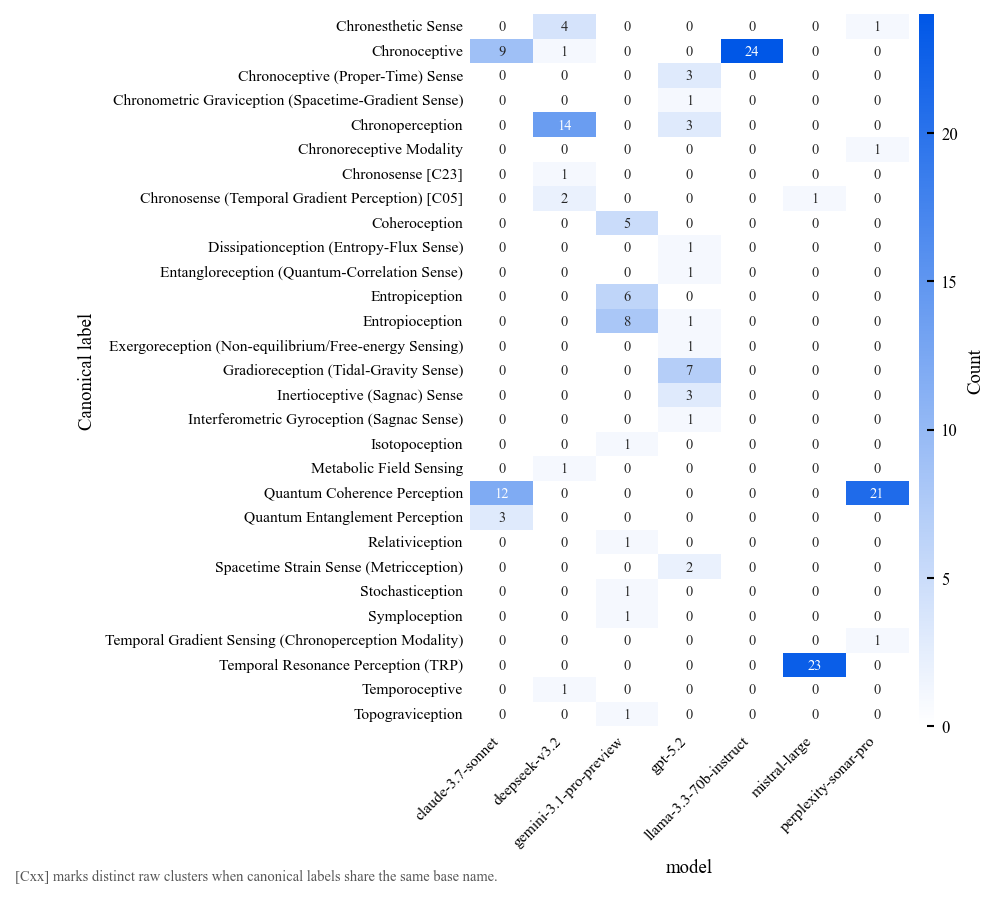

In [108]:
# Step 4. Apply canonical labels to all 168 rows and export compression artifacts.
compression_dir = Path("results/test1/proposal_compression")
compression_dir.mkdir(parents=True, exist_ok=True)

# Map unique proposal_name -> canonical label.
name_to_canonical = unique_work_df[["proposal_name", "canonical_label", "final_cluster_key", "raw_cluster_id"]].copy()

compressed_all = ai_df.merge(
    name_to_canonical,
    on="proposal_name",
    how="left",
    validate="many_to_one",
)

if compressed_all["canonical_label"].isna().any():
    missing = compressed_all.loc[compressed_all["canonical_label"].isna(), "proposal_name"].unique().tolist()
    raise ValueError(f"Unmapped proposal names found: {missing[:10]}")

final_summary = (
    compressed_all.groupby("canonical_label")
    .agg(
        total_rows=("proposal_id", "count"),
        unique_names=("proposal_name", "nunique"),
        models=("model", "nunique"),
    )
    .sort_values(["total_rows", "unique_names"], ascending=[False, False])
    .reset_index()
)

# Optional model-by-cluster table for paper appendix.
model_cluster_table = pd.crosstab(compressed_all["canonical_label"], compressed_all["model"])

# Save outputs.
unique_exact_df.to_csv(compression_dir / "01_unique_exact_names.csv", index=False)
unique_work_df.sort_values(["canonical_label", "proposal_name"]).to_csv(
    compression_dir / "02_unique_names_with_clusters.csv", index=False
)
compressed_all.to_csv(compression_dir / "03_all_168_with_canonical_labels.csv", index=False)
final_summary.to_csv(compression_dir / "04_canonical_cluster_summary.csv", index=False)
model_cluster_table.to_csv(compression_dir / "05_canonical_by_model_table.csv")

# Compact table-like heatmap for canonical x model counts.
# Preserve exact canonical labels, and add raw-cluster IDs only when base names collide.
from collections import Counter
import re as _re

label_to_cluster = (
    unique_work_df.groupby("canonical_label", as_index=False)["raw_cluster_id"]
    .first()
    .set_index("canonical_label")["raw_cluster_id"]
    .to_dict()
)

def _base_hm_label(label: str) -> str:
    return _re.sub(r"\s*\(.*?\)\s*$", "", str(label)).strip()

base_counts = Counter(_base_hm_label(lbl) for lbl in model_cluster_table.index)

def _display_hm_label(label: str) -> str:
    s = str(label).strip()
    base = _base_hm_label(s)
    if base_counts[base] > 1:
        return f"{s} [C{int(label_to_cluster[label]):02d}]"
    return s

label_map = {lbl: _display_hm_label(lbl) for lbl in model_cluster_table.index}
plot_table = model_cluster_table.rename(index=label_map)

n_rows = len(plot_table)
fig_h = max(5.0, 0.17 * n_rows + 1.4)
fig, ax = plt.subplots(figsize=(6.9, fig_h))
sns.heatmap(
    plot_table,
    cmap=WHITE_SKY_CMAP,
    annot=True,
    fmt=".0f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Count", "aspect": 48, "pad": 0.02},
    ax=ax,
)
# ax.set_title("Canonical Proposal Clusters by Model")
ax.set_ylabel("Canonical label")
# ax.set_xlabel("model")
ax.tick_params(left=False, bottom=False)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7.5, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7.5, rotation=45, ha="right")
fig.subplots_adjust(left=0.45, right=0.96, bottom=0.18, top=0.93)

fig.text(
    0.01,
    0.015,
    "[Cxx] marks distinct raw clusters when canonical labels share the same base name.",
    ha="left",
    va="bottom",
    fontsize=7,
    color="#555555",
    transform=fig.transFigure,
)

plt.savefig(compression_dir / "06_canonical_by_model_heatmap.png", bbox_inches="tight")
print(f"Saved model-cluster heatmap: {compression_dir / '06_canonical_by_model_heatmap.png'}")
plt.show()


**Figure caption.** Canonical cluster label distribution by model. Each row is a model; each column is a canonical cluster; cell shading encodes the number of proposals assigned to that cluster by that model.

In [71]:
print("Step 4 complete")
print(f"Rows preserved after compression mapping: {len(compressed_all)} (expected 168)")
print(f"Canonical clusters: {final_summary.shape[0]}")
print(f"Saved artifacts to: {compression_dir}")
display(final_summary)
display(model_cluster_table)

Step 4 complete
Rows preserved after compression mapping: 168 (expected 168)
Canonical clusters: 29
Saved artifacts to: results/test1/proposal_compression


,canonical_label,total_rows,unique_names,models
0,C08: Chronoceptive,34,3,3
1,C19: Quantum Coherence Perception,33,3,2
2,C26: Temporal Resonance Perception (TRP),23,1,1
3,C09: Chronoperception,17,3,2
4,C02: Entropioception,9,4,2
5,C11: Gradioreception (Tidal-Gravity Sense),7,6,1
6,C27: Entropiception,6,1,1
7,C07: Chronesthetic Sense,5,4,2
8,C01: Coheroception,5,2,1
9,C03: Inertioceptive (Sagnac) Sense,3,3,1


model,claude-3.7-sonnet,deepseek-v3.2,gemini-3.1-pro-preview,gpt-5.2,llama-3.3-70b-instruct,mistral-large,perplexity-sonar-pro
canonical_label,,,,,,,
C01: Coheroception,0,0,5,0,0,0,0
C02: Entropioception,0,0,8,1,0,0,0
C03: Inertioceptive (Sagnac) Sense,0,0,0,3,0,0,0
C04: Spacetime Strain Sense (Metricception),0,0,0,2,0,0,0
C05: Chronosense (Temporal Gradient Perception),0,2,0,0,0,1,0
C06: Chronoceptive (Proper-Time) Sense,0,0,0,3,0,0,0
C07: Chronesthetic Sense,0,4,0,0,0,0,1
C08: Chronoceptive,9,1,0,0,24,0,0
C09: Chronoperception,0,14,0,3,0,0,0


## 7. Detailed Examples Analysis

In [72]:
test1_results = pd.read_csv(path_test1_results)

# If classification is absent (e.g., section 6 cell was skipped), derive a lightweight fallback.
if "classification" not in test1_results.columns:
    if "is_novel" in test1_results.columns:
        test1_results["classification"] = np.where(
            test1_results["is_novel"].astype(str).str.upper().eq("NO"),
            "Literature Traceable",
            "Recombination",
        )
    elif "ontologically_novel" in test1_results.columns:
        # Legacy fallback
        test1_results["classification"] = np.where(
            test1_results["ontologically_novel"].astype(str).str.upper().eq("NO"),
            "Literature Traceable",
            "Recombination",
        )
    else:
        test1_results["classification"] = "Unclassified"

name_col = "proposal_name" if "proposal_name" in test1_results.columns else "modality_name"
desc_col = "description" if "description" in test1_results.columns else "lit_best_text"
nov_col = "novelty_score" if "novelty_score" in test1_results.columns else "novelty_score_proxy"

if nov_col not in test1_results.columns:
    sim = pd.to_numeric(test1_results.get("max_similarity", np.nan), errors="coerce")
    test1_results[nov_col] = (1.0 - sim).clip(lower=0.0, upper=1.0)

print("\n=== REPRESENTATIVE EXAMPLES ===")

for classification in test1_results["classification"].astype(str).unique():
    print(f"\n{classification}:")
    examples = test1_results[test1_results["classification"] == classification].head(2)
    for _, ex in examples.iterrows():
        novelty_val = float(pd.to_numeric(ex.get(nov_col, np.nan), errors="coerce"))
        sim_val = float(pd.to_numeric(ex.get("max_similarity", np.nan), errors="coerce"))
        print(f"\n  Model: {ex.get('model', 'N/A')}")
        print(f"  Proposal: {ex.get(name_col, 'N/A')}")
        print(f"  Description: {str(ex.get(desc_col, ''))[:200]}...")
        print(f"  Novelty Score: {novelty_val:.2f}")
        print(f"  Similarity to Literature: {sim_val:.3f}")
        print(f"  Inside Hull: {bool(ex.get('inside_convex_hull', False))}")

# Export updated detailed results (including classification, etc.)
test1_results.to_csv("results/test1/detailed_results.csv", index=False)
print("\n=== TEST 1 ANALYSIS COMPLETE ===")
print("Results saved to results/test1/")


=== REPRESENTATIVE EXAMPLES ===

Literature Traceable:

  Model: deepseek-v3.2
  Proposal: Chronesthesia
  Description: This paper introduces the concept of Human State Field as a proposed framework for understanding how individuals perceive and experience time. We explore how various internal and external inputs affec...
  Novelty Score: 0.55
  Similarity to Literature: 0.449
  Inside Hull: True

  Model: mistral-large
  Proposal: Temporal Resonance Perception (TRP)
  Description: This paper introduces the concept of Human State Field as a proposed framework for understanding how individuals perceive and experience time. We explore how various internal and external inputs affec...
  Novelty Score: 0.70
  Similarity to Literature: 0.298
  Inside Hull: True

=== TEST 1 ANALYSIS COMPLETE ===
Results saved to results/test1/
